# Semi-synthetic results

This notebook reports the completed multi-dataset CoxPH-margin experiment with Gaussian, Clayton, Frank, and Gumbel copulas from `results/semi-synthetic`. It loads the cross-dataset aggregate when available, otherwise combines the completed per-dataset result files. The semi-synthetic cohorts retain each source dataset's original censoring rate.

In [19]:
from pathlib import Path
import os
import re
import shutil
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "large",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}",
    "savefig.bbox": "tight",
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
})

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
CONFIG_PATH = ROOT / "configs" / "semi_synthetic.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)
RESULT_CANDIDATES = [ROOT / "results" / "semi-synthetic"]
FIGURE_DIR = ROOT / "paper" / "figures"
TABLE_DIR = ROOT / "paper" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
RANK_TAU = 0.5  # prediction results are reported at this dependence level only

# Display names for dataset slugs, in the order datasets are shown in figures;
# anything unmapped falls back to the slug with its underscores escaped, since
# text.usetex is on.
DATASET_LABEL = {
    "whas": "WHAS",
    "metabric": "METABRIC",
    "churn": "Churn",
    "gbsg": "GBSG",
    "nacd": "NACD",
    "flchain": "FLChain",
    "support": "SUPPORT",
    "employee": "Employee",
    "mimic_all": "MIMIC-IV",
    "mimic_iv": "MIMIC-IV",
    "seer_brain": "SEER (brain)",
    "seer_liver": "SEER (liver)",
    "seer_stomach": "SEER (stomach)",
}

def dataset_label(name):
    return DATASET_LABEL.get(str(name), str(name).replace("_", r"\_"))

def order_datasets(names):
    """Figure order: DATASET_LABEL key order, then anything unmapped, alphabetically."""
    observed = {str(name) for name in names}
    ordered = [name for name in DATASET_LABEL if name in observed]
    return ordered + sorted(observed.difference(ordered))

In [20]:
def snake_case(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

def canonicalize(frame):
    out = frame.rename(columns={column: snake_case(column) for column in frame.columns}).copy()
    aliases = {
        "dataset_name": "dataset", "target_censoring": "target_censoring_rate",
        "censoring_rate": "target_censoring_rate", "kendall_tau": "target_kendall_tau",
        "oracle_joint_ise": "oracle_joint_survival_ise",
    }
    out = out.rename(columns={key: value for key, value in aliases.items() if key in out and value not in out})
    if "model" in out:
        names = {"dvfm": "DVFM", "coxph": "CoxPH", "deepsurv": "DeepSurv", "rsf": "RSF",
                 "gbsa": "GBSA", "mtlr": "MTLR", "hacsurv": "HACSurv",
                 "hacsurv_2d": "HACSurv", "clayton_aft": "ClaytonAFT",
                 "bayesian_cox_gamma_frailty": "BayesianCoxGammaFrailty", "bayesiancoxgammafrailty": "BayesianCoxGammaFrailty"}
        out["model"] = out["model"].astype(str).str.lower().map(names).fillna(out["model"].astype(str))
        if "latent_dim" in out:
            latent_dim = pd.to_numeric(out["latent_dim"], errors="coerce")
            nonprimary = out["model"].eq("DVFM") & latent_dim.ne(1) & latent_dim.notna()
            out.loc[nonprimary, "model"] = latent_dim.loc[nonprimary].map(lambda value: f"DVFM-z{int(value)}")
    if "copula" in out:
        out["copula"] = out["copula"].astype(str).str.title()
    return out

result_path = next((path / "results_raw.csv" for path in RESULT_CANDIDATES if (path / "results_raw.csv").exists()), None)
if result_path is not None:
    results = canonicalize(pd.read_csv(result_path))
    DATA_SOURCE = "REAL RESULTS (cross-dataset aggregate)"
else:
    dataset_result_paths = [
        result for root in RESULT_CANDIDATES if root.exists()
        for result in sorted(root.glob("*/results_raw.csv"))
    ]
    if not dataset_result_paths:
        searched = ", ".join(str(path.relative_to(ROOT)) for path in RESULT_CANDIDATES)
        raise FileNotFoundError(f"No semi-synthetic results found in: {searched}")
    results = canonicalize(pd.concat((pd.read_csv(path) for path in dataset_result_paths), ignore_index=True))
    DATA_SOURCE = f"REAL RESULTS ({len(dataset_result_paths)} completed dataset jobs)"

required = {"dataset", "copula", "target_kendall_tau", "target_censoring_rate", "repeat", "model", "oracle_ibs"}
missing = required - set(results.columns)
if missing:
    raise ValueError(f"Results are missing canonical columns: {sorted(missing)}")

CONFIG_TAU_VALUES = [float(value) for value in config["data"]["kendall_tau"]]
CONFIG_POSITIVE_COPULAS = {name.title() for name in config["data"]["copulas"]}
tau = pd.to_numeric(results["target_kendall_tau"], errors="coerce")
configured_tau = np.isclose(tau.to_numpy()[:, None], np.asarray(CONFIG_TAU_VALUES)).any(axis=1)
configured_copula = (np.isclose(tau, 0.0) & results["copula"].eq("Independence")) \
| (~np.isclose(tau, 0.0) & results["copula"].isin(CONFIG_POSITIVE_COPULAS))
results = results.loc[configured_tau & configured_copula].copy()
if results.empty:
    raise ValueError("No rows match the active semi_synthetic.yaml condition grid.")
# DVFM z=0 is the matched no-frailty ablation, not a competing method. It is
# kept out of `results`, which drives the recovery diagnostics and every
# per-method summary, and enters only two places: its own paired comparison
# against z=1, and `ranked_results`, the frame the rank displays use. Ranks are
# relative, so the ablation has to be inside the pool to have one at all; every
# display built from `ranked_results` therefore ranks nine entries, not eight.
ABLATION_MODELS = ["DVFM-z0"]
ablation = results[results["model"].isin(ABLATION_MODELS)].copy()
results = results[~results["model"].isin(ABLATION_MODELS)].copy()
if results.empty:
    raise ValueError("Every row was classified as an ablation row.")
if ablation.empty:
    raise ValueError(
        "No DVFM z=0 rows. Rerun the semi-synthetic workflow with dvfm_z0 in "
        "models.enabled."
    )
ranked_results = pd.concat([results, ablation], ignore_index=True)

dataset_specs = {item["name"]: item for item in config["data"]["datasets"]}
characteristics = (
    results.groupby("dataset", as_index=False)
    .agg(**{"$N$": ("num_samples", "median"),
            "Encoded features": ("num_features", "median"),
            "Original censoring rate": ("target_censoring_rate", "median")})
    .rename(columns={"dataset": "Dataset"})
)
characteristics["Raw features"] = characteristics["Dataset"].map(
    lambda name: len(dataset_specs[name].get("numeric_features", [])) + len(dataset_specs[name].get("categorical_features", []))
)
characteristics["Split"] = "70/10/20"
characteristics = characteristics[["Dataset", "$N$", "Raw features", "Encoded features", "Original censoring rate", "Split"]]
for column in ["$N$", "Raw features", "Encoded features"]:
    characteristics[column] = characteristics[column].round().astype(int)

print(DATA_SOURCE, f"| rows={len(results):,} | datasets={results['dataset'].nunique()}")

REAL RESULTS (cross-dataset aggregate) | rows=4,800 | datasets=12


## Shared-latent recovery hexbin plot

Hexbin density makes the held-out subject-level recovery relationship legible without overplotting. The two panels use the real SUPPORT semi-synthetic exports at target $\tau=0.50$, pooling standardized held-out subject-run observations across the ten repeats for the Gaussian and Clayton copulas. Each repeat retains its own validation-derived calibration; no test subjects are used to fit an affine mapping.

Image 2 (pooled across copula families, one dataset, one operating condition) is answering: does recovery hold up across different dependence structures? It's a robustness claim about model misspecification of the copula family, not about censoring at all — censored and event-observed subjects are pooled together in each hexbin.

So they're not redundant; they're stress-testing DVFM along two orthogonal axes (censoring status vs. copula family), and a reader benefits from seeing both rather than just one standing in for the other.

Gaussian: 562 of 17750 subjects fall outside the plotted window


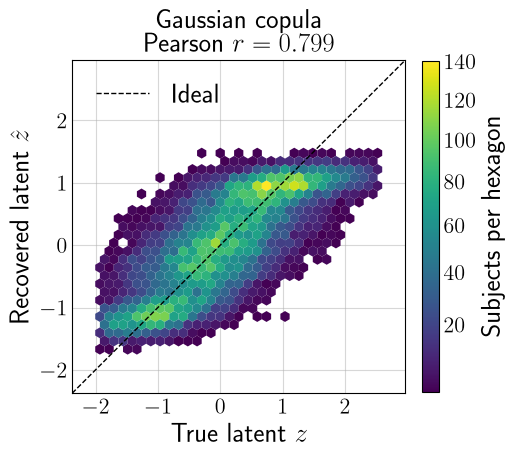

support (gridsize 30): {'Gaussian': 17750}
wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_frailty_recovery_support_gaussian.pdf


In [21]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.ticker import MaxNLocator

# ============================== settings =====================================
DATASET = "support"                # any dataset named in semi_synthetic.yaml
COPULAS = ("Gaussian",)             # None -> every configured copula, one panel each
TAU = 0.50                          # must be one of the configured kendall_tau values
POOL_REPEATS = True                 # False -> a single repeat
REPEAT = None                       # None -> first configured seed; only used if not pooling

X_COLUMN, X_LABEL = "true_z", "True latent $z$"
Y_COLUMN, Y_LABEL = "learned_z_calibrated", "Recovered latent $\\hat{z}$"

CLIP_PCT_LOW = 2.0             # raise to trim more of an empty tail
CLIP_PCT_HIGH = 99.5           # top edge; leave alone unless it clips real data
BIN_PAD_FRAC = 0.05            # padding baked into the hexbin extent (affects what's binned)
VIEW_PAD_FRAC = 0.10           # extra margin around the hexagons, axes only -> raise to zoom out
TARGET_COUNT = 25              # median subjects per hexagon; sets the gridsize
MINCNT = 1
CMAP = "viridis"
NORM_GAMMA = 0.8               # < 1 brightens sparse bins; 1.0 is linear

PANEL_SIZE = (5.0, 4.6)        # inches per panel
GUIDE = dict(color="black", linestyle="--", linewidth=1)
GRID = dict(alpha=0.5)
FIGURE_STEM = "semi_synthetic_frailty_recovery"
# ============================================================================

def repeat_from_latent_path(path):
    seed_parts = [part for part in path.parts if part.startswith("seed_")]
    if len(seed_parts) != 1:
        raise ValueError(f"Cannot identify the repeat from latent export: {path}")
    return int(seed_parts[0].removeprefix("seed_"))

def latent_run_paths(dataset, copula, tau, pool_repeats, repeat):
    token = f"_{copula}_tau_{tau:g}_"
    matches = sorted(
        path for root in RESULT_CANDIDATES if (root / dataset).exists()
        for path in (root / dataset).rglob("latent_recovery_test.csv")
        if token in path.parent.name.lower()
    )
    if not matches:
        raise FileNotFoundError(f"No latent exports found for {dataset}/{copula} at tau={tau:g}.")
    if len(matches) != len(config["seeds"]):
        warnings.warn(
            f"Expected {len(config['seeds'])} {dataset}/{copula} seeds at tau={tau:g}; "
            f"found {len(matches)} (some may be unavailable_no_true_frailty)."
        )
    if pool_repeats:
        return matches
    selected = [path for path in matches if repeat_from_latent_path(path) == repeat]
    if len(selected) != 1:
        raise FileNotFoundError(
            f"Expected one {dataset}/{copula} latent export for repeat {repeat}; found {len(selected)}."
        )
    return selected

def occupied_counts(image):
    counts = image.get_array()
    return np.asarray(counts[~np.ma.getmaskarray(counts)], dtype=float)

def choose_gridsize(extents_xy, target, start=42, bounds=(16, 64), mincnt=1):
    """Pick the gridsize whose sparsest panel has ~target subjects per hexagon."""
    scratch_fig, scratch_ax = plt.subplots()
    size = start
    for _ in range(4):
        medians = []
        for x, y, extent in extents_xy:
            trial = scratch_ax.hexbin(x, y, gridsize=size, extent=extent, mincnt=mincnt)
            counts = occupied_counts(trial)
            medians.append(float(np.median(counts)) if counts.size else 0.0)
            trial.remove()
        median = min(medians)
        if median <= 0:
            break
        adjusted = int(np.clip(round(size * np.sqrt(median / target)), *bounds))
        if adjusted == size:
            break
        size = adjusted
    plt.close(scratch_fig)
    return size

def render_latent_recovery_hexbin(
    dataset, copulas, tau, pool_repeats, repeat,
    x_column, x_label, y_column, y_label,
    clip_pct_low, clip_pct_high, bin_pad_frac, view_pad_frac,
    target_count, mincnt, cmap, norm_gamma,
    panel_size, guide, grid, figure_stem,
    nrows=1, ncols=None,
):
    """Build and save one shared-latent recovery hexbin figure, one panel per copula."""
    dataset_names = [item["name"] for item in config["data"]["datasets"]]
    if dataset not in dataset_names:
        raise ValueError(f"{dataset!r} is not a configured dataset: {dataset_names}")
    configured_taus = [float(value) for value in config["data"]["kendall_tau"]]
    if not np.isclose(tau, configured_taus).any():
        raise ValueError(f"tau={tau:g} is not configured: {configured_taus}")
    repeat = config["seeds"][0] if repeat is None else repeat

    copula_tokens = {name.title(): name.lower() for name in config["data"]["copulas"]}
    if copulas is not None:
        unknown = [name for name in copulas if name not in copula_tokens]
        if unknown:
            raise ValueError(f"Copulas {unknown} are not configured: {sorted(copula_tokens)}")
        copula_tokens = {name: copula_tokens[name] for name in copulas}

    hexbin_runs = {
        label: latent_run_paths(dataset, token, tau, pool_repeats, repeat)
        for label, token in copula_tokens.items()
    }
    hexbin_subjects = {
        label: pd.concat((pd.read_csv(path) for path in paths), ignore_index=True)
        for label, paths in hexbin_runs.items()
    }
    density_label = f"{'Subjects' if pool_repeats else 'Test subjects'} per hexagon"

    panels = []
    for label, part in hexbin_subjects.items():
        missing_columns = {x_column, y_column} - set(part.columns)
        if missing_columns:
            raise ValueError(f"{dataset} latent data are missing columns: {sorted(missing_columns)}")

        x = part[x_column].to_numpy()
        y = part[y_column].to_numpy()

        # Robust range shared by both axes, from both variables together.
        low, high = np.nanpercentile(np.r_[x, y], [clip_pct_low, clip_pct_high])
        bin_pad = bin_pad_frac * (high - low)
        bin_low, bin_high = low - bin_pad, high + bin_pad

        # Drop points outside the binning window so the edge hexagons are not inflated.
        inside = (x >= bin_low) & (x <= bin_high) & (y >= bin_low) & (y <= bin_high)
        if (~inside).any():
            print(f"{label}: {(~inside).sum()} of {len(x)} subjects fall outside the plotted window")

        # Separate, wider margin for the axes themselves -- zooms out without rebinning.
        view_pad = view_pad_frac * (bin_high - bin_low)
        view_low, view_high = bin_low - view_pad, bin_high + view_pad

        panels.append((label, x[inside], y[inside],
                       (bin_low, bin_high, bin_low, bin_high), (view_low, view_high)))

    gridsize = choose_gridsize(
        [(x, y, extent) for _, x, y, extent, _ in panels], target=target_count, mincnt=mincnt
    )

    n_panels = len(panels)
    ncols = n_panels if ncols is None else ncols
    if nrows * ncols < n_panels:
        raise ValueError(f"{nrows}x{ncols} grid cannot hold {n_panels} panels.")
    fig, axes = plt.subplots(nrows, ncols, squeeze=False, constrained_layout=True,
                             figsize=(panel_size[0] * ncols, panel_size[1] * nrows))
    fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)
    for ax in axes.flat[n_panels:]:
        ax.set_visible(False)
    images = []

    for ax, (label, x, y, extent, view) in zip(axes.flat, panels):
        view_low, view_high = view
        images.append(ax.hexbin(x, y, gridsize=gridsize, extent=extent, mincnt=mincnt,
                                cmap=cmap, linewidths=0, zorder=2,
                                rasterized=True))
        ax.plot([view_low, view_high], [view_low, view_high], label="Ideal", zorder=3, **guide)

        ax.set_xlim(view_low, view_high)
        ax.set_ylim(view_low, view_high)
        ax.set_aspect("equal", adjustable="box")
        ticks = MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10]).tick_values(view_low, view_high)
        ticks = ticks[(ticks >= view_low) & (ticks <= view_high)]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.grid(True, zorder=0, **grid)
        ax.set_axisbelow(True)

        correlation = hexbin_subjects[label][[x_column, y_column]].corr().iloc[0, 1]
        ax.set(title=f"{label} copula\nPearson $r = {correlation:.3f}$",
               xlabel=x_label, ylabel=y_label)
        ax.legend(frameon=False, loc="upper left")

    # A single norm across every panel, so one colorbar describes them all.
    norm = PowerNorm(gamma=norm_gamma, vmin=mincnt,
                     vmax=max(float(occupied_counts(image).max()) for image in images))
    for image in images:
        image.set_norm(norm)
    fig.colorbar(images[-1], ax=axes, label=density_label, shrink=0.8)
    for col in range(axes.shape[1]):
        fig.align_ylabels(axes[:, col])

    suffix = "" if pool_repeats else f"_repeat_{repeat}"
    copula_tag = "_".join(name.lower() for name in copula_tokens)
    out = FIGURE_DIR / f"{figure_stem}_{dataset}_{copula_tag}{suffix}.pdf"
    # 400 dpi for the rasterized hexagons; axes and text stay vector.
    fig.savefig(out, dpi=400)
    plt.show()
    print(f"{dataset} (gridsize {gridsize}):", {label: len(part) for label, part in hexbin_subjects.items()})
    print(f"wrote {out}")
    return fig, hexbin_subjects

fig, hexbin_subjects = render_latent_recovery_hexbin(
    DATASET, COPULAS, TAU, POOL_REPEATS, REPEAT,
    X_COLUMN, X_LABEL, Y_COLUMN, Y_LABEL,
    CLIP_PCT_LOW, CLIP_PCT_HIGH, BIN_PAD_FRAC, VIEW_PAD_FRAC,
    TARGET_COUNT, MINCNT, CMAP, NORM_GAMMA,
    PANEL_SIZE, GUIDE, GRID, FIGURE_STEM,
)

Gaussian: 562 of 17750 subjects fall outside the plotted window
Clayton: 611 of 17750 subjects fall outside the plotted window
Frank: 129 of 17750 subjects fall outside the plotted window
Gumbel: 198 of 17750 subjects fall outside the plotted window


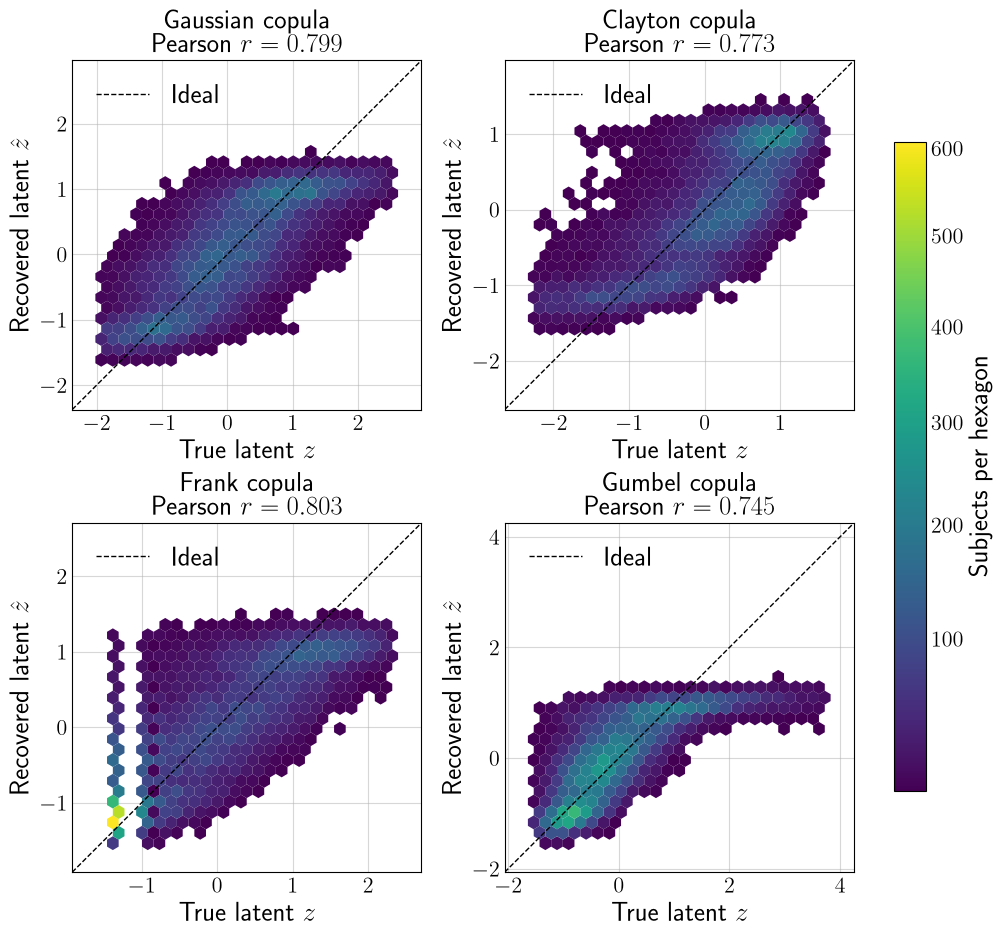

support (gridsize 25): {'Gaussian': 17750, 'Clayton': 17750, 'Frank': 17750, 'Gumbel': 17750}
wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_frailty_recovery_support_gaussian_clayton_frank_gumbel.pdf


In [22]:
# ============================== settings =====================================
DATASET = "support"
COPULAS = ("Gaussian", "Clayton", "Frank", "Gumbel")   # None -> every configured copula
TAU = 0.50
POOL_REPEATS = True
REPEAT = None

X_COLUMN, X_LABEL = "true_z", "True latent $z$"
Y_COLUMN, Y_LABEL = "learned_z_calibrated", "Recovered latent $\\hat{z}$"

CLIP_PCT_LOW = 2.0             # raise to trim more of an empty tail
CLIP_PCT_HIGH = 99.5           # top edge; leave alone unless it clips real data
BIN_PAD_FRAC = 0.05            # padding baked into the hexbin extent (affects what's binned)
VIEW_PAD_FRAC = 0.10           # extra margin around the hexagons, axes only -> raise to zoom out
TARGET_COUNT = 25              # median subjects per hexagon; sets the gridsize
MINCNT = 1
CMAP = "viridis"
NORM_GAMMA = 0.8               # < 1 brightens sparse bins; 1.0 is linear

PANEL_SIZE = (5.0, 4.6)
GUIDE = dict(color="black", linestyle="--", linewidth=1)
GRID = dict(alpha=0.5)
FIGURE_STEM = "semi_synthetic_frailty_recovery"
# ============================================================================
# Reuses render_latent_recovery_hexbin (and its helpers) defined in the cell above.

fig, hexbin_subjects = render_latent_recovery_hexbin(
    DATASET, COPULAS, TAU, POOL_REPEATS, REPEAT,
    X_COLUMN, X_LABEL, Y_COLUMN, Y_LABEL,
    CLIP_PCT_LOW, CLIP_PCT_HIGH, BIN_PAD_FRAC, VIEW_PAD_FRAC,
    TARGET_COUNT, MINCNT, CMAP, NORM_GAMMA,
    PANEL_SIZE, GUIDE, GRID, FIGURE_STEM, 
    nrows=2, ncols=2,
)

In [23]:
frank = hexbin_subjects["Frank"]
low_tail = frank[frank["true_z"] < -1.0]
print("subjects in tail:", len(low_tail))
print("distinct true_z values:", low_tail["true_z"].nunique())
print(low_tail["true_z"].value_counts().head(10))

subjects in tail: 3079
distinct true_z values: 10
true_z
-1.338040    323
-1.348652    323
-1.334844    321
-1.335414    319
-1.323730    319
-1.335361    314
-1.351301    313
-1.366289    285
-1.350155    283
-1.359122    279
Name: count, dtype: int64


## Figure 1: model ranks across semi-synthetic datasets

Models are compared separately at target Kendall's $\tau=0$ and $\tau=0.5$. The independence condition supplies the $\tau=0$ row. At $\tau=0.5$, ranks are computed within each paired dataset/copula/seed/metric cell and then averaged equally over seeds and the Gaussian, Clayton, Frank, and Gumbel copulas within each dataset. A failed model receives one rank below the worst successful model in its paired cell. Rank 1 is best. Points show median dataset ranks; horizontal bars are 95% non-parametric bootstrap intervals obtained by resampling datasets. The matched no-frailty control, DVFM with $d_z=0$, is ranked in the same pool as the benchmarks and drawn as a hollow star: its distance from the filled star is what the shared latent buys on the same leaderboard, read in the same units as every other gap in the panel. Because ranks are relative, including it makes this a nine-entry pool, so ranks here are not comparable with an eight-model ranking.

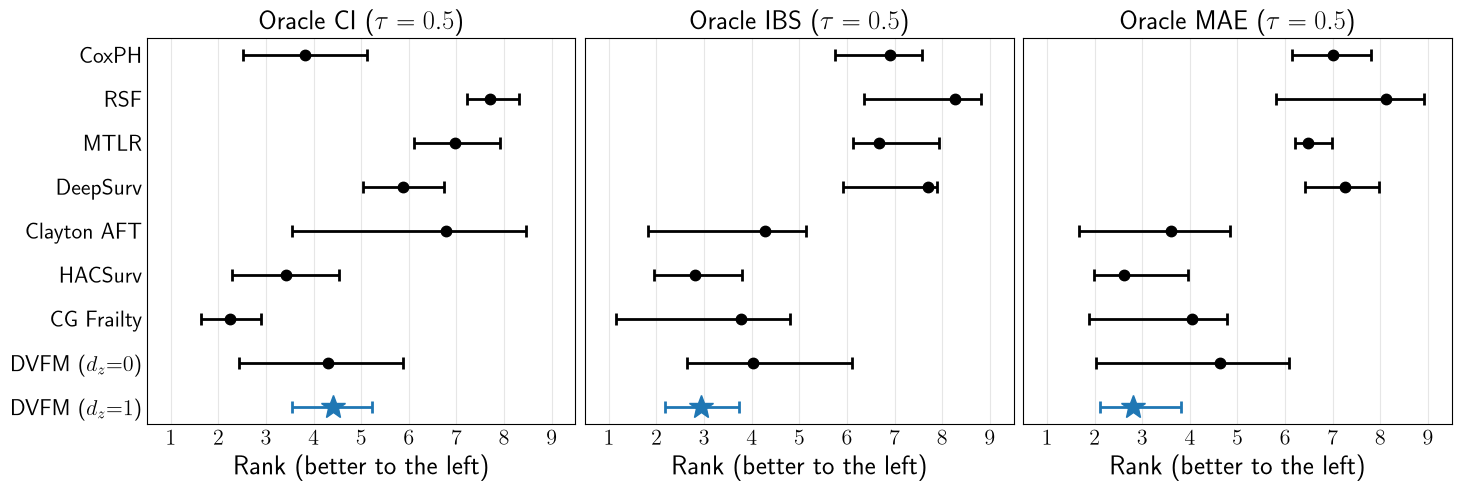

REAL RESULTS (cross-dataset aggregate) | 12 datasets; tau=0.5; 10,000 dataset bootstraps | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_model_ranks.pdf


In [24]:
RANK_METRICS = {
    "oracle_ci": ("Oracle CI", True),
    "oracle_ibs": ("Oracle IBS", False),
    "oracle_mae": ("Oracle MAE", False),
}
N_BOOTSTRAPS = 10_000
BOOTSTRAP_SEED = 0
MODEL_LABELS = {
    "DVFM": r"DVFM ($d_z{=}1$)",
    "DVFM-z0": r"DVFM ($d_z{=}0$)",
    "BayesianCoxGammaFrailty": "CG Frailty",
    "RSF": "RSF",
    "GBSA": "Gradient Boosting",
    "ClaytonAFT": "Clayton AFT", "HACSurv": "HACSurv",
}

SEED_KEYS = ["dataset", "copula", "target_kendall_tau", "target_censoring_rate", "repeat"]
EXPECTED_REPEATS = len(config["seeds"])

def seed_level_metric_ranks(frame, metric, higher_is_better):
    """Rank paired runs, penalizing only the atomic seeds that failed."""
    work = frame[SEED_KEYS + ["model", metric, "numerical_failure"]].copy()
    if work.duplicated(SEED_KEYS + ["model"]).any():
        raise ValueError(f"Duplicate model rows found while ranking {metric}.")
    values = pd.to_numeric(work[metric], errors="coerce")
    failure = work["numerical_failure"].fillna(False)
    if failure.dtype != bool:
        failure = failure.astype(str).str.lower().eq("true")
    valid = np.isfinite(values) & ~failure
    work["_score"] = values.where(valid)
    work["seed_rank"] = work.groupby(SEED_KEYS)["_score"].rank(
        ascending=not higher_is_better, method="min"
    )
    worst_completed = work.groupby(SEED_KEYS)["seed_rank"].transform("max")
    if worst_completed[~valid].isna().any():
        raise ValueError(f"A {metric} seed cell has no successful model to define a failure rank.")
    work.loc[~valid, "seed_rank"] = worst_completed.loc[~valid] + 1
    work["failed"] = ~valid
    return work

# Rank within paired seeds first. For tau=0.5, average the four
# copula-specific ranks equally within each dataset before bootstrapping datasets.
rank_tables_by_tau = {}
tau_value = RANK_TAU

# The no-frailty ablation is ranked alongside the benchmarks: it is the same
# architecture and the same tuned hyperparameters with the shared latent
# removed, so its rank is what the latent is worth on the leaderboard the
# benchmarks are read off.
rank_input = ranked_results[
    np.isclose(ranked_results["target_kendall_tau"], tau_value)
].copy()
if rank_input.empty:
    raise ValueError(f"No results for tau={tau_value:g}.")
expected_copulas = {"Independence"} if np.isclose(tau_value, 0.0) else CONFIG_POSITIVE_COPULAS
observed_copulas = set(rank_input["copula"].unique())
if observed_copulas != expected_copulas:
    raise ValueError(
        f"Unexpected copulas for tau={tau_value:g}: expected {sorted(expected_copulas)}, "
        f"found {sorted(observed_copulas)}."
    )
rank_tables = {}
for metric, (_, higher_is_better) in RANK_METRICS.items():
    seed_ranks = seed_level_metric_ranks(rank_input, metric, higher_is_better)
    repeat_counts = seed_ranks.groupby(["dataset", "copula", "model"])["repeat"].nunique()
    if not repeat_counts.eq(EXPECTED_REPEATS).all():
        incomplete = repeat_counts[~repeat_counts.eq(EXPECTED_REPEATS)]
        raise ValueError(
            f"Incomplete seed grid for tau={tau_value:g}, {metric}: {incomplete.to_dict()}"
        )
    scenario_ranks = (
        seed_ranks.groupby(["dataset", "copula", "model"], as_index=False)["seed_rank"].mean()
    )
    rank_tables[metric] = (
        scenario_ranks.groupby(["dataset", "model"])["seed_rank"].mean().unstack("model")
    )
rank_tables_by_tau[tau_value] = rank_tables

all_rank_tables = [
    table for rank_tables in rank_tables_by_tau.values() for table in rank_tables.values()
]
# Fixed display order, top to bottom on the axis: baselines grouped by family
# (classical, machine learning, copula, frailty) with our model anchoring the
# bottom. Vertical position is a family grouping, not a performance ordering.
MODEL_ORDER = ["CoxPH", "RSF", "MTLR", "DeepSurv", "ClaytonAFT", "HACSurv",
               "BayesianCoxGammaFrailty", "DVFM-z0", "DVFM"]

models = set.intersection(*(set(table.columns) for table in all_rank_tables))
if not models:
    raise ValueError("No model has all three rank metrics.")
absent = [name for name in MODEL_ORDER if name not in models]
unlisted = sorted(models - set(MODEL_ORDER))
if absent or unlisted:
    raise ValueError(
        f"Rank tables disagree with MODEL_ORDER: absent={absent}, unlisted={unlisted}"
    )
model_order = list(MODEL_ORDER)

rng = np.random.default_rng(BOOTSTRAP_SEED)
rank_intervals = {}
for tau_value, rank_tables in rank_tables_by_tau.items():
    rank_intervals[tau_value] = {}
    for metric, ranks in rank_tables.items():
        values = ranks.reindex(columns=model_order).to_numpy(dtype=float)
        sampled_rows = rng.integers(0, len(values), size=(N_BOOTSTRAPS, len(values)))
        bootstrap_medians = np.median(values[sampled_rows], axis=1)
        rank_intervals[tau_value][metric] = pd.DataFrame(
            {"median": np.median(values, axis=0),
             "low": np.quantile(bootstrap_medians, 0.025, axis=0),
             "high": np.quantile(bootstrap_medians, 0.975, axis=0)},
            index=model_order,
        )

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), sharex=True, sharey=True, constrained_layout=True)
positions = np.arange(len(model_order))
for axis, (metric, (title, _)) in zip(axes, RANK_METRICS.items()):
    interval = rank_intervals[RANK_TAU][metric].loc[model_order]
    for y_pos, (model, row) in enumerate(interval.iterrows()):
        # Only the reported model is highlighted; its d_z=0 ablation is drawn
        # like every other comparator, and the axis label distinguishes them.
        is_dvfm = model == "DVFM"
        axis.errorbar(
            row["median"], y_pos,
            xerr=[[row["median"] - row["low"]], [row["high"] - row["median"]]],
            fmt="*" if is_dvfm else "o",
            markersize=18 if is_dvfm else 7.5,
            elinewidth=2.0, capsize=4.5, capthick=2.0,
            color="tab:blue" if is_dvfm else "black",
        )
    axis.set(
        title=rf"{title} ($\tau={RANK_TAU:g}$)",
        xlabel="Rank (better to the left)",
        xlim=(0.5, len(model_order) + 0.5),
    )
    axis.set_xticks(np.arange(1, len(model_order) + 1))
    axis.grid(axis="x", color="0.9", linewidth=0.8)
axes[0].set(
    yticks=positions,
    yticklabels=[MODEL_LABELS.get(model, model) for model in model_order]
)
axes[0].invert_yaxis()
out = FIGURE_DIR / "semi_synthetic_model_ranks.pdf"
fig.savefig(out, bbox_inches="tight")
plt.show()
print(
    f"{DATA_SOURCE} | {results['dataset'].nunique()} datasets; "
    f"tau={RANK_TAU:g}; {N_BOOTSTRAPS:,} dataset bootstraps | wrote {out}"
)

## Figure 2: recovery diagnostics

The horizontal axis is target Kendall's $\tau$, the active experimental factor. For each dataset, metrics are averaged over seeds before pooling; intervals use datasetsâ€”not pooled subjects or seedsâ€”as the unit of uncertainty. Each dataset retains its original censoring rate, which is deliberately not used as a plotting stratum.

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_latent_recovery.pdf
REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_dependence_calibration.pdf


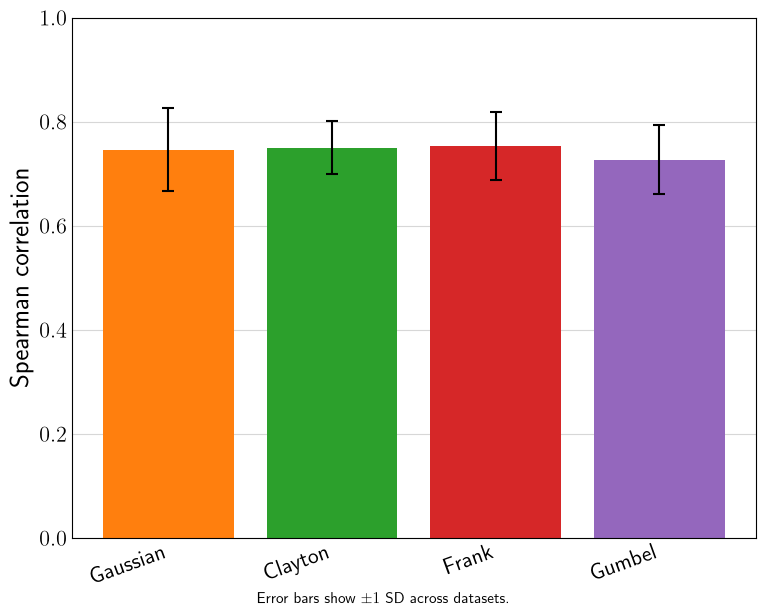

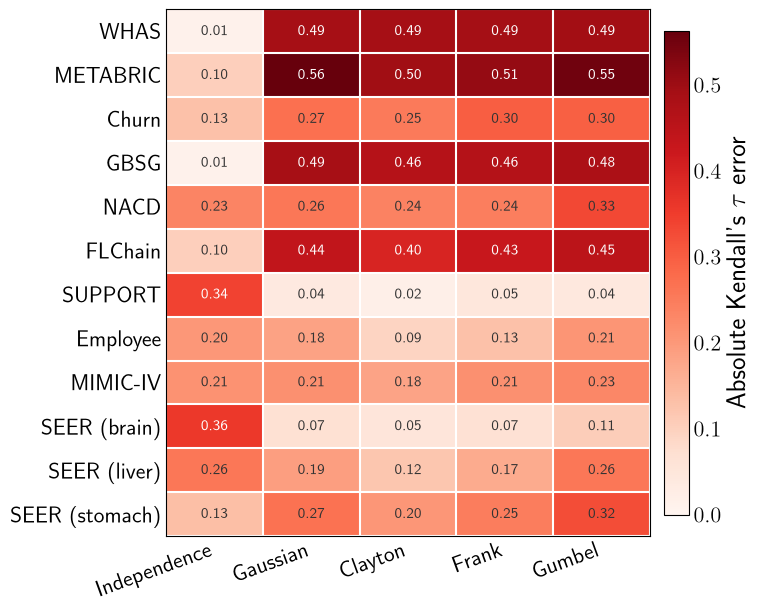

In [25]:
def dataset_balanced_summary(frame, metric, sigma_level=1.0):
    # Average seeds within each dataset, then quantify cross-dataset variation.
    per_dataset = frame.groupby(["dataset", "copula", "target_kendall_tau"], as_index=False)[metric].mean()
    out = per_dataset.groupby(["copula", "target_kendall_tau"])[metric].agg(["mean", "std", "count"]).reset_index()
    out["error"] = sigma_level * out["std"].fillna(0)
    return out

dvfm = results[results["model"].eq("DVFM")].copy()

copula_order = ["Independence"] + [name.title() for name in config["data"]["copulas"]]
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
palette = dict(zip(copula_order, default_colors[:len(copula_order)]))
positive_taus = [tau for tau in CONFIG_TAU_VALUES if not np.isclose(tau, 0.0)]

# Both panels are saved at one size and without a tight bounding box, so a LaTeX
# subfigure pair scales them identically instead of by their trimmed content.
SUBFIG_SIZE = (7.5, 6.0)

# -- Individual shared-latent recovery ---------------------------------------
# include_independence=False: frailty recovery is undefined at tau=0 (SYNTHETIC.md), not zero.
RECOVERY_METRIC = "frailty_spearman"
summary = dataset_balanced_summary(dvfm, RECOVERY_METRIC, sigma_level=1.0)  # +/- 1 SD across datasets

bar_specs = [(copula, tau) for copula in copula_order[1:] for tau in positive_taus]
means, errors, colors, tick_labels = [], [], [], []
for copula, tau in bar_specs:
    row = summary[(summary["copula"] == copula) & np.isclose(summary["target_kendall_tau"], tau)]
    if row.empty:
        raise ValueError(f"No {RECOVERY_METRIC} summary for {copula} at tau={tau:g}.")
    mean_value = float(row["mean"].iloc[0])
    if not np.isfinite(mean_value):
        raise ValueError(f"{RECOVERY_METRIC} is undefined for {copula} at tau={tau:g}.")
    means.append(mean_value)
    errors.append(float(row["error"].iloc[0]))
    colors.append(palette[copula])
    tick_labels.append(copula if len(positive_taus) <= 1 else f"{copula}\n$\\tau={tau:g}$")

means = np.array(means)
errors = np.array(errors)
# Spearman correlation can't go below 0 here -- clip the lower whisker rather
# than let it imply impossible values; the upper whisker is untouched.
lower_err = np.minimum(errors, means)
x_positions = np.arange(len(bar_specs))

fig, ax = plt.subplots(figsize=SUBFIG_SIZE, constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)
ax.bar(x_positions, means, yerr=[lower_err, errors], color=colors, capsize=4,
       error_kw=dict(elinewidth=1.5, capthick=1.5))
ax.set_xticks(x_positions, tick_labels, rotation=20, ha="right")
ax.set(ylabel="Spearman correlation", ylim=(0.0, 1.0))
ax.grid(axis="y", alpha=0.5)
ax.set_axisbelow(True)
fig.supxlabel("Error bars show $\\pm 1$ SD across datasets.", fontsize=11)

out = FIGURE_DIR / "semi_synthetic_latent_recovery.pdf"
with plt.rc_context({"savefig.bbox": "standard"}):  # exact SUBFIG_SIZE, no content-dependent trim
    fig.savefig(out)
print(f"{DATA_SOURCE} | wrote {out}")

# -- Dependence calibration, every dataset x copula cell ---------------------
# The copula is the least informative axis (the spread across the four dependent
# copulas within a dataset is ~7x smaller than the spread between datasets), so
# the grid shows all 60 cells rather than averaging one of them away.
CAL_ABS = "absolute_conditional_kendall_tau_error"
cal_cells = dvfm.groupby(["dataset", "copula"], as_index=False)[CAL_ABS].mean()  # seeds first
cal_datasets = order_datasets(cal_cells["dataset"].unique())
grid = (
    cal_cells.pivot_table(index="dataset", columns="copula", values=CAL_ABS)
    .reindex(index=cal_datasets, columns=copula_order)
)
if grid.isna().any().any():
    raise ValueError("The calibration heatmap has empty dataset x copula cells.")

fig, ax = plt.subplots(figsize=SUBFIG_SIZE, constrained_layout=True)
values = grid.to_numpy(dtype=float)
image = ax.imshow(values, cmap="Reds", aspect="auto", vmin=0.0)
ax.set_xticks(np.arange(len(copula_order)), copula_order, rotation=20, ha="right")
ax.set_yticks(np.arange(len(cal_datasets)), [dataset_label(name) for name in cal_datasets])
# White seams between the cells so each value reads as its own tile.
ax.set_xticks(np.arange(len(copula_order) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(cal_datasets) + 1) - 0.5, minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)
threshold = 0.6 * float(values.max())
for row, column in np.ndindex(values.shape):
    value = float(values[row, column])
    ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=11,
            color="white" if value > threshold else "0.2")
ax.grid(which="major", visible=False)
fig.colorbar(image, ax=ax, label=r"Absolute Kendall's $\tau$ error",
             fraction=0.05, pad=0.03)

out = FIGURE_DIR / "semi_synthetic_dependence_calibration.pdf"
with plt.rc_context({"savefig.bbox": "standard"}):  # exact SUBFIG_SIZE, no content-dependent trim
    fig.savefig(out)
print(f"{DATA_SOURCE} | wrote {out}")

plt.show()

## Figure 2c: where the dependence becomes identifiable

The calibration grid varies far more between datasets than between copulas. This
figure plots the learned conditional Kendall's $	au$ against the number of
uncensored training events, the quantity that actually constrains the latent
scale, with the two targets as dashed lines. Each dataset contributes one marker
per target; the vertical stub joins the pair, so its length is the model's
response to a $0 
ightarrow 0.5$ change in the true dependence.


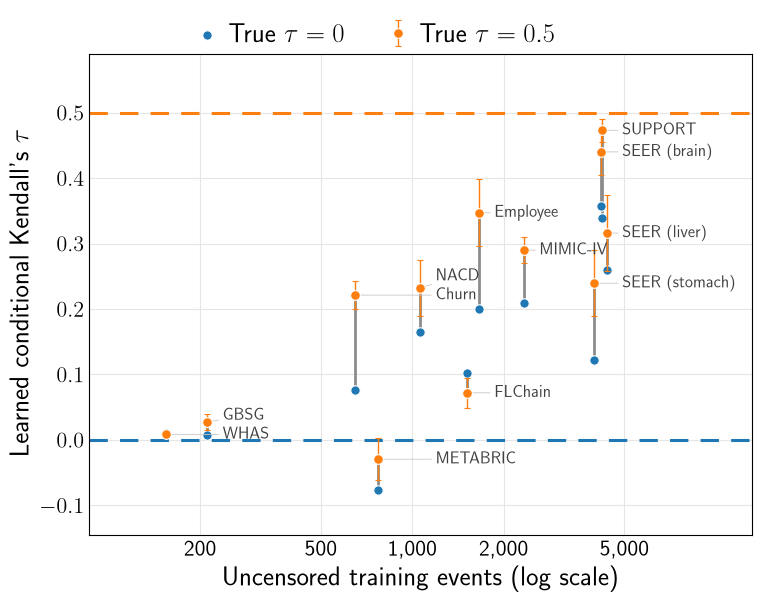

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_tau_vs_training_events.pdf
learned tau at target 0.5 vs training events: Spearman rho=+0.85
response to the 0 -> 0.5 change in true tau: mean +0.072, corr(tau at 0, tau at 0.5)=0.95


In [26]:
# Learned dependence against the amount of signal available to identify it.
# The latent scale is what sets the induced Kendall's tau, and it is the part of
# the fit the likelihood constrains least, so it needs uncensored events to be
# pinned down. One marker per dataset per target tau, at the dataset's training
# event count; the dashed lines are the two targets.
EVENT_FIGURE_SIZE = SUBFIG_SIZE
if len(positive_taus) != 1:
    raise ValueError(f"This figure assumes a single positive tau, found {positive_taus}.")
POSITIVE_TAU = positive_taus[0]
TAU0_COLOR, TAU1_COLOR = default_colors[0], default_colors[1]
TRAIN_FRACTION = 1.0 - float(config["split"]["validation_fraction"]) - float(config["split"]["test_fraction"])
CAL_TAU = "learned_conditional_kendall_tau"
DATASET_LABEL_SIZE = 12  # point size of the dataset names in the plot

def label_points(ax, xs, ys, names, dx=11.0, cluster_points=32.0, gap_points=3.0):
    """Right-hand point labels with leader lines.

    Labels whose anchors crowd horizontally are aligned to the right edge of
    their cluster, so text never runs across a neighbouring marker, and any
    that still overlap vertically are pushed apart.
    """
    figure = ax.figure
    texts = [
        ax.annotate(name, (x_value, y_value), textcoords="offset points",
                    xytext=(dx, 0.0), ha="left", va="center", fontsize=DATASET_LABEL_SIZE, color="0.25",
                    arrowprops=dict(arrowstyle="-", color="0.78", linewidth=0.6,
                                    shrinkA=1, shrinkB=2))
        for name, x_value, y_value in zip(names, xs, ys)
    ]
    figure.canvas.draw()  # window extents need a laid-out figure
    to_points = 72.0 / figure.dpi
    anchors = ax.transData.transform(np.column_stack([xs, ys])) * to_points
    clusters = []
    for index in np.argsort(anchors[:, 0]):
        if clusters and anchors[index, 0] - anchors[clusters[-1][-1], 0] <= cluster_points:
            clusters[-1].append(index)
        else:
            clusters.append([index])
    for cluster in clusters:
        right_edge = max(anchors[index, 0] for index in cluster)
        for index in cluster:
            texts[index].set_position((dx + right_edge - anchors[index, 0], 0.0))

    figure.canvas.draw()
    boxes = [text.get_window_extent() for text in texts]
    order = sorted(range(len(texts)), key=lambda index: boxes[index].y0)
    shifts = [0.0] * len(texts)  # pixels
    for position, index in enumerate(order):
        for other in order[:position]:
            lower, upper = boxes[other], boxes[index]
            if upper.x1 <= lower.x0 or lower.x1 <= upper.x0:
                continue  # side by side, so they cannot collide
            needed = (lower.y1 + shifts[other]) + gap_points / to_points - (upper.y0 + shifts[index])
            if needed > 0:
                shifts[index] += needed
    for text, shift in zip(texts, shifts):
        if abs(shift) > 0.5:
            offset_x, offset_y = text.xyann
            text.set_position((offset_x, offset_y + shift * to_points))
    return texts

cells = dvfm.groupby(["dataset", "copula"], as_index=False).agg(
    learned_tau=(CAL_TAU, "mean"),  # seeds first
    num_samples=("num_samples", "median"),
    event_rate_train=("event_rate_train", "median"),
)
events = (
    cells.groupby("dataset")
    .apply(lambda part: TRAIN_FRACTION * part["num_samples"].iloc[0] * part["event_rate_train"].iloc[0],
           include_groups=False)
    .rename("train_events")
)
at_zero = cells[cells["copula"].eq("Independence")].set_index("dataset")["learned_tau"]
dependent_tau = cells[cells["copula"].isin(copula_order[1:])].groupby("dataset")["learned_tau"].agg(["mean", "std"])
event_datasets = order_datasets(cells["dataset"].unique())
if not set(event_datasets) <= set(at_zero.index) & set(dependent_tau.index):
    raise ValueError("Every dataset needs both an Independence and a dependent-copula fit.")

x = events.reindex(event_datasets).to_numpy(dtype=float)
y_zero = at_zero.reindex(event_datasets).to_numpy(dtype=float)
y_dependent = dependent_tau["mean"].reindex(event_datasets).to_numpy(dtype=float)
y_spread = dependent_tau["std"].reindex(event_datasets).fillna(0).to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=EVENT_FIGURE_SIZE, constrained_layout=True)
for target, color in ((0.0, TAU0_COLOR), (POSITIVE_TAU, TAU1_COLOR)):
    ax.axhline(target, color=color, linestyle=(0, (6, 4)), linewidth=2.2, zorder=1)
ax.vlines(x, np.minimum(y_zero, y_dependent), np.maximum(y_zero, y_dependent),
          color="0.55", linewidth=2.0, zorder=2)
ax.scatter(x, y_zero, s=46, color=TAU0_COLOR, zorder=3, edgecolor="white", linewidth=0.8,
           label=r"True $\tau=0$")
ax.errorbar(x, y_dependent, yerr=y_spread, fmt="o", markersize=7, color=TAU1_COLOR,
            linestyle="none", elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=3,
            markeredgecolor="white", markeredgewidth=0.8,
            label=rf"True $\tau={POSITIVE_TAU:g}$")

ax.set_xscale("log")
# Decade ticks are too sparse over 155-4400 events and matplotlib's log minor
# labels ("2 x 10^2") collide, so label a fixed set and drop the minor ones.
event_ticks = [200, 500, 1000, 2000, 5000]
ax.set_xticks(event_ticks, [f"{tick:,}" for tick in event_ticks])
ax.set_xticks([], minor=True)
ax.set_xlim(x.min() / 1.8, x.max() * 3.0)  # right margin holds the dataset labels
ax.set_ylim(min(y_zero.min(), y_dependent.min()) - 0.07,
            max(POSITIVE_TAU, y_dependent.max()) + 0.09)
ax.set_xlabel("Uncensored training events (log scale)")
ax.set_ylabel(r"Learned conditional Kendall's $\tau$")
ax.grid(color="0.9", linewidth=0.8)
ax.set_axisbelow(True)
fig.legend(loc="outside upper center", ncol=2, frameon=False, columnspacing=2.0, handlelength=0.01)

label_points(ax, x, y_dependent, [dataset_label(name) for name in event_datasets])

out = FIGURE_DIR / "semi_synthetic_tau_vs_training_events.pdf"
with plt.rc_context({"savefig.bbox": "standard"}):
    fig.savefig(out)
plt.show()

rho = pd.Series(y_dependent, index=event_datasets).corr(pd.Series(x, index=event_datasets), method="spearman")
print(f"{DATA_SOURCE} | wrote {out}")
print(f"learned tau at target {POSITIVE_TAU:g} vs training events: Spearman rho={rho:+.2f}")
print(f"response to the 0 -> {POSITIVE_TAU:g} change in true tau: "
      f"mean {np.mean(y_dependent - y_zero):+.3f}, "
      f"corr(tau at 0, tau at {POSITIVE_TAU:g})={np.corrcoef(y_zero, y_dependent)[0, 1]:.2f}")

## Calibration error: DVFM against HACSurv

The panel above reports DVFM's learned Kendall's $\tau$ on its own. Both DVFM and HACSurv estimate the same quantity here, because the semi-synthetic shared latent is drawn independently of the covariates, so the conditional $\tau$ equals the target for every subject. The two estimators differ: DVFM's is a Monte Carlo estimate through its decoder at the mean covariate, HACSurv's is an analytic property of its fitted Archimedean generator. Only the signed error against the known target is comparable across models, which is what this figure plots.

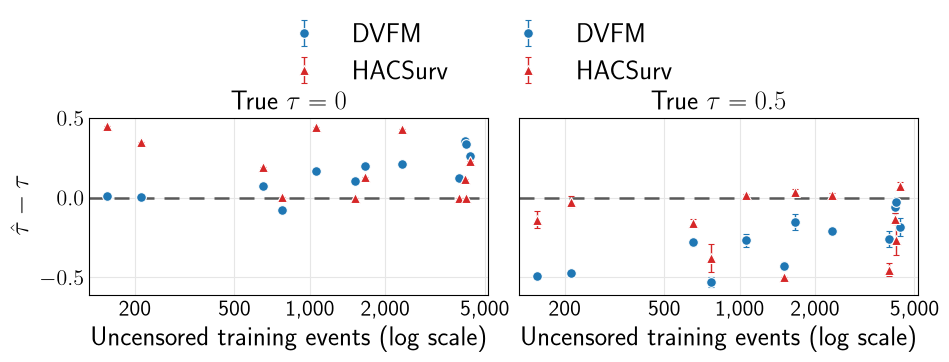

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_tau_error_dvfm_vs_hacsurv.pdf
DVFM Monte Carlo standard error at 10,000 pairs: 0.0067
                             mean  median    std  count
model   target_kendall_tau                             
DVFM    0.0                 0.148   0.144  0.134     12
        0.5                -0.280  -0.264  0.168     12
HACSurv 0.0                 0.196   0.161  0.183     12
        0.5                -0.158  -0.135  0.198     12
tau=0: median signed error DVFM +0.144 vs HACSurv +0.161 over 12 datasets, Wilcoxon p=0.569
tau=0.5: median signed error DVFM -0.264 vs HACSurv -0.135 over 12 datasets, Wilcoxon p=0.0771


In [27]:
# Both models record a learned conditional Kendall's tau, but they compute it
# differently: DVFM by Monte Carlo through its decoder at the mean covariate,
# HACSurv analytically from its fitted Archimedean generator. The estimand is
# the same, because the semi-synthetic shared latent is drawn independently of
# X, so the conditional tau equals the target for every subject. Only the
# signed error against that known target is comparable across the two models;
# the raw values are not (AGENTS.md).
from scipy.stats import wilcoxon

TAU_ERROR_MODELS = ("DVFM", "HACSurv")
TAU_ERROR_COLORS = dict(zip(TAU_ERROR_MODELS, (default_colors[0], default_colors[3])))
TAU_ERROR_MARKERS = {"DVFM": "o", "HACSurv": "^"}
# Monte Carlo standard error of DVFM's estimate at the configured sample size.
DVFM_TAU_MC_SE = float(np.sqrt(2 * (2 * config["evaluation"]["dependence_samples"] + 5)
                               / (9.0 * config["evaluation"]["dependence_samples"]
                                  * (config["evaluation"]["dependence_samples"] - 1))))

missing_tau = [
    name for name in TAU_ERROR_MODELS
    if name not in set(results["model"]) or results.loc[results["model"].eq(name), CAL_TAU].isna().all()
]
if missing_tau:
    raise ValueError(f"No learned Kendall's tau was recorded for: {missing_tau}")

tau_cells = (
    results[results["model"].isin(TAU_ERROR_MODELS)]
    .groupby(["model", "dataset", "copula", "target_kendall_tau"], as_index=False)
    .agg(learned_tau=(CAL_TAU, "mean"),
         num_samples=("num_samples", "median"),
         event_rate_train=("event_rate_train", "median"))
)
tau_cells["tau_error"] = tau_cells["learned_tau"] - tau_cells["target_kendall_tau"]
# Seeds first, then the copulas within a dataset, so every dataset contributes
# one marker per target tau exactly as in the figure above.
tau_panels = (
    tau_cells.groupby(["model", "dataset", "target_kendall_tau"], as_index=False)
    .agg(tau_error=("tau_error", "mean"), tau_error_sd=("tau_error", "std"),
         num_samples=("num_samples", "median"),
         event_rate_train=("event_rate_train", "median"))
)
tau_panels["train_events"] = (
    TRAIN_FRACTION * tau_panels["num_samples"] * tau_panels["event_rate_train"]
)

TAU_LEVELS = [0.0, POSITIVE_TAU]
fig, axes = plt.subplots(1, 2, figsize=(SUBFIG_SIZE[0] * 1.25, SUBFIG_SIZE[1] * 0.60),
                         sharey=True, constrained_layout=True)
for ax, target in zip(axes, TAU_LEVELS):
    ax.axhline(0.0, color="0.35", linestyle=(0, (6, 4)), linewidth=1.8, zorder=1)
    for name in TAU_ERROR_MODELS:
        subset = tau_panels[
            tau_panels["model"].eq(name)
            & np.isclose(tau_panels["target_kendall_tau"], target)
        ].sort_values("train_events")
        ax.errorbar(subset["train_events"], subset["tau_error"],
                    yerr=subset["tau_error_sd"].fillna(0.0),
                    fmt=TAU_ERROR_MARKERS[name], markersize=7,
                    color=TAU_ERROR_COLORS[name], linestyle="none",
                    elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=3,
                    markeredgecolor="white", markeredgewidth=0.8, label=name)
    ax.set_xscale("log")
    event_ticks = [200, 500, 1000, 2000, 5000]
    ax.set_xticks(event_ticks, [f"{tick:,}" for tick in event_ticks])
    ax.set_xticks([], minor=True)
    ax.set_title(rf"True $\tau={target:g}$")
    ax.set_xlabel("Uncensored training events (log scale)")
    ax.grid(color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].set_ylabel(r"$\hat{\tau} - \tau$")
fig.legend(loc="outside upper center", ncol=2, frameon=False, columnspacing=2.0)

out = FIGURE_DIR / "semi_synthetic_tau_error_dvfm_vs_hacsurv.pdf"
with plt.rc_context({"savefig.bbox": "standard"}):
    fig.savefig(out)
plt.show()

print(f"{DATA_SOURCE} | wrote {out}")
print(f"DVFM Monte Carlo standard error at "
      f"{config['evaluation']['dependence_samples']:,} pairs: {DVFM_TAU_MC_SE:.4f}")
print(tau_panels.groupby(["model", "target_kendall_tau"])["tau_error"]
      .agg(["mean", "median", "std", "count"]).round(3).to_string())
for target in TAU_LEVELS:
    wide = tau_panels[np.isclose(tau_panels["target_kendall_tau"], target)].pivot(
        index="dataset", columns="model", values="tau_error"
    ).dropna()
    if len(wide) < 2:
        raise ValueError(f"Too few paired datasets at tau={target:g} to compare models.")
    test = wilcoxon(wide["DVFM"], wide["HACSurv"])
    print(f"tau={target:g}: median signed error DVFM {wide['DVFM'].median():+.3f} vs "
          f"HACSurv {wide['HACSurv'].median():+.3f} over {len(wide)} datasets, "
          f"Wilcoxon p={test.pvalue:.3g}")

## The matched no-frailty ablation

Every DVFM job fits the reported $z=1$ model and a $z=0$ control with the same architecture, tuned hyperparameters, cohort and split, so the two are paired by construction. Under independence the true joint surface is the product of the margins, which $z=0$ can represent exactly, so the joint ISE at $\tau=0$ measures the cost of DVFM's spurious dependence there. Under dependence the same comparison is the ablation supporting the claim that the gains require the shared-latent pathway. The event-margin metrics at $\tau=0$ separately test whether the latent is absorbing marginal misfit.

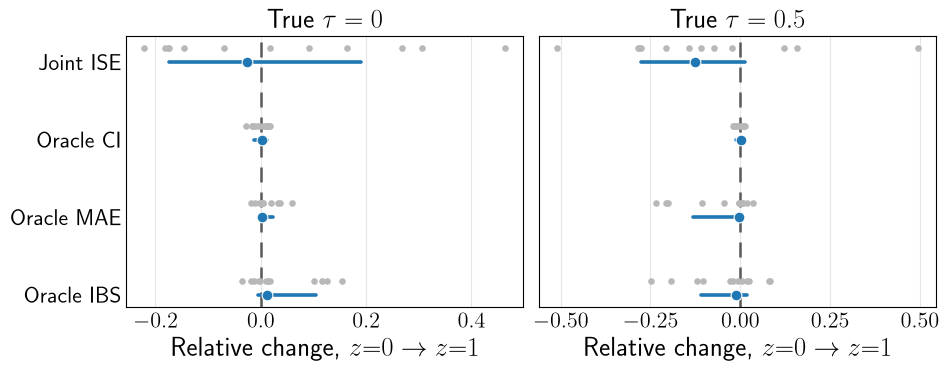

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_latent_ablation.pdf and c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_latent_ablation.tex
paired cells: 600 | datasets: 12
 Target $\tau$     Metric Better  Median change  IQR low  IQR high  Datasets  Wilcoxon $p$
           0.0 Oracle IBS  lower         0.0119  -0.0053    0.1049        12        0.2036
           0.0 Oracle MAE  lower         0.0026  -0.0014    0.0225        12        0.1763
           0.0  Oracle CI higher         0.0015  -0.0133    0.0112        12        0.9697
           0.0  Joint ISE  lower        -0.0261  -0.1740    0.1895        12        0.8501
           0.5 Oracle IBS  lower        -0.0126  -0.1085    0.0196        12        0.2661
           0.5 Oracle MAE  lower        -0.0035  -0.1308    0.0064        12        0.3013
           0.5  Oracle CI higher         0.0018  -0.0121    0.0059        12        0.6221
           0.5  Joint

In [28]:
# Matched no-frailty ablation. z=0 and z=1 are fitted inside one job from the
# same cohort, split and tuned hyperparameters, so every cell is paired by
# construction rather than by seed agreement. Reported as the relative change
# from z=0 to z=1: seeds are averaged within a dataset x copula cell, the
# copulas are averaged within a dataset, and the 12 datasets give the median
# and interquartile range, matching the aggregation used for the rank tables.
from scipy.stats import wilcoxon

ABLATION_METRICS = {
    "oracle_ibs": ("Oracle IBS", "lower"),
    "oracle_mae": ("Oracle MAE", "lower"),
    "oracle_ci": ("Oracle CI", "higher"),
    "oracle_joint_survival_ise": ("Joint ISE", "lower"),
}
ABLATION_KEYS = [
    "dataset", "copula", "target_kendall_tau", "target_censoring_rate", "repeat",
]

if ablation.empty:
    raise FileNotFoundError(
        "No DVFM z=0 rows. Rerun the semi-synthetic workflow with "
        "models.dvfm.latent_dims: [1, 0]."
    )

def _usable(frame, metrics):
    failure = frame.get("numerical_failure", pd.Series(False, index=frame.index))
    if failure.dtype != bool:
        failure = failure.astype(str).str.lower().eq("true")
    keep = ~failure.fillna(False)
    for metric in metrics:
        keep &= np.isfinite(pd.to_numeric(frame[metric], errors="coerce"))
    return frame[keep]

metrics = list(ABLATION_METRICS)
primary = _usable(results[results["model"].eq("DVFM")].copy(), metrics)
control = _usable(ablation.copy(), metrics)
paired = primary.merge(
    control[ABLATION_KEYS + metrics], on=ABLATION_KEYS,
    suffixes=("_z1", "_z0"), validate="one_to_one",
)
cell_counts = paired.groupby(ABLATION_KEYS[:-1])["repeat"].nunique()
if not cell_counts.eq(EXPECTED_REPEATS).all():
    incomplete = cell_counts[~cell_counts.eq(EXPECTED_REPEATS)]
    raise ValueError(f"Incomplete paired ablation cells: {incomplete.to_dict()}")

for metric in metrics:
    paired[f"{metric}_change"] = (
        (paired[f"{metric}_z1"] - paired[f"{metric}_z0"])
        / paired[f"{metric}_z0"].abs()
    )
change_columns = [f"{metric}_change" for metric in metrics]
per_copula = paired.groupby(
    ["dataset", "copula", "target_kendall_tau"], as_index=False
)[change_columns].mean()
per_dataset = per_copula.groupby(
    ["dataset", "target_kendall_tau"], as_index=False
)[change_columns].mean()

ablation_rows = []
for tau_value in CONFIG_TAU_VALUES:
    subset = per_dataset[np.isclose(per_dataset["target_kendall_tau"], tau_value)]
    if subset.empty:
        raise ValueError(f"No paired ablation cells at tau={tau_value:g}.")
    for metric in metrics:
        label, direction = ABLATION_METRICS[metric]
        values = subset[f"{metric}_change"].dropna()
        lower, upper = np.percentile(values, [25, 75])
        test = wilcoxon(values) if len(values) > 1 else None
        ablation_rows.append({
            "Target $\\tau$": tau_value,
            "Metric": label,
            "Better": direction,
            "Median change": float(np.median(values)),
            "IQR low": float(lower),
            "IQR high": float(upper),
            "Datasets": int(len(values)),
            "Wilcoxon $p$": float(test.pvalue) if test is not None else np.nan,
        })
ablation_table = pd.DataFrame(ablation_rows)

fig, axes = plt.subplots(
    1, len(CONFIG_TAU_VALUES),
    figsize=(SUBFIG_SIZE[0] * 1.25, SUBFIG_SIZE[1] * 0.60),
    sharey=True, constrained_layout=True,
)
axes = np.atleast_1d(axes)
metric_labels = [ABLATION_METRICS[metric][0] for metric in metrics]
positions = np.arange(len(metrics))
for ax, tau_value in zip(axes, CONFIG_TAU_VALUES):
    subset = per_dataset[np.isclose(per_dataset["target_kendall_tau"], tau_value)]
    ax.axvline(0.0, color="0.35", linestyle=(0, (6, 4)), linewidth=1.8, zorder=1)
    for position, metric in zip(positions, metrics):
        values = subset[f"{metric}_change"].dropna().to_numpy()
        median = float(np.median(values))
        lower, upper = np.percentile(values, [25, 75])
        ax.scatter(values, np.full(len(values), position) + 0.18, s=14,
                   color="0.72", zorder=2)
        ax.plot([lower, upper], [position, position], color=default_colors[0],
                linewidth=2.6, solid_capstyle="round", zorder=3)
        ax.scatter([median], [position], s=60, color=default_colors[0],
                   zorder=4, edgecolor="white", linewidth=0.8)
    ax.set_yticks(positions, metric_labels)
    ax.invert_yaxis()
    ax.set_title(rf"True $\tau={tau_value:g}$")
    ax.set_xlabel(r"Relative change, $z{=}0 \rightarrow z{=}1$")
    ax.grid(color="0.9", linewidth=0.8, axis="x")
    ax.set_axisbelow(True)

out = FIGURE_DIR / "semi_synthetic_latent_ablation.pdf"
with plt.rc_context({"savefig.bbox": "standard"}):
    fig.savefig(out)
plt.show()

formatted = ablation_table.copy()
formatted["Change"] = [
    f"{row['Median change']:+.1%} [{row['IQR low']:+.1%}, {row['IQR high']:+.1%}]"
    .replace("%", r"\%")
    for _, row in formatted.iterrows()
]
formatted["Wilcoxon $p$"] = formatted["Wilcoxon $p$"].map(lambda value: f"{value:.3f}")
latex = formatted[
    ["Target $\\tau$", "Metric", "Better", "Change", "Datasets", "Wilcoxon $p$"]
].to_latex(index=False, escape=False, column_format="llllrr")
table_path = TABLE_DIR / "semi_synthetic_latent_ablation.tex"
table_path.write_text(latex, encoding="utf-8")

print(f"{DATA_SOURCE} | wrote {out} and {table_path}")
print(f"paired cells: {len(paired):,} | datasets: {per_dataset['dataset'].nunique()}")
print(ablation_table.round(4).to_string(index=False))

## Figure 2b: joint-distribution recovery, DVFM vs. HACSurv

Panel C of Figure 2 is the only recovery diagnostic that both DVFM and HACSurv
export: `oracle_joint_survival_ise` is populated for those two models and for no
other baseline (the shared-latent and Kendall's $	au$ calibration metrics are
DVFM-only). The grid is balanced -- 12 datasets $	imes$ 5 copulas $	imes$ 10
repeat/fold runs per model -- so the comparison is paired at the dataset
$	imes$ copula cell level.

The figure is paired per dataset on a log axis: repeats are averaged within each
dataset $	imes$ copula cell, then the five copulas are averaged into one marker
per model, with $\pm 1$ SD across those copulas as the whisker. A log axis is
required because ISE ranges roughly 60$	imes$ across datasets (`nacd` to
`flchain`), which would otherwise swamp the separation between the two models.


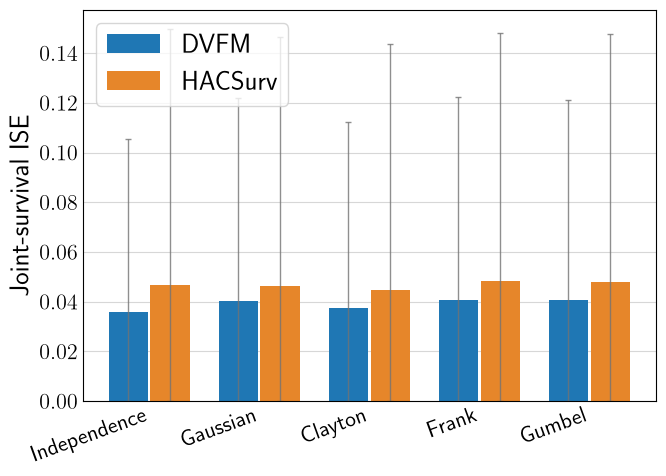

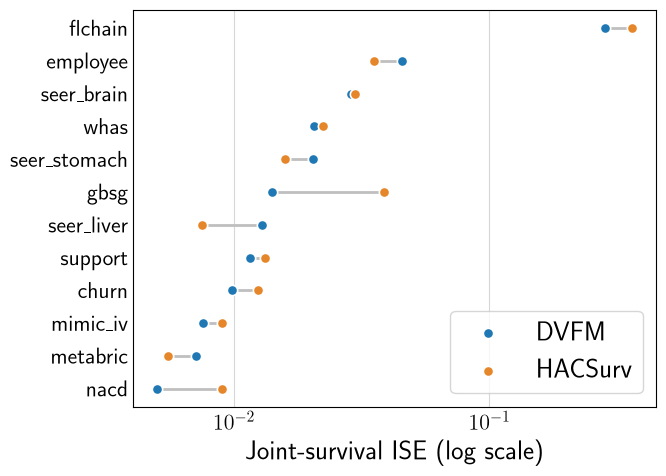

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_joint_recovery_by_copula.pdf and c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_joint_recovery_by_dataset.pdf
dataset-balanced mean ISE: DVFM=0.0389 HACSurv=0.0469
DVFM lower in 37/60 dataset x copula cells (paired Wilcoxon W=702, p=0.117)


In [29]:
JOINT_METRIC = "oracle_joint_survival_ise"
JOINT_MODELS = ("DVFM", "HACSurv")
JOINT_COLORS = {"DVFM": "#1f77b4", "HACSurv": "#e6862a"}

def tex_escape(name):
    return str(name).replace("_", r"\_")

joint = results[results[JOINT_METRIC].notna() & results["model"].isin(JOINT_MODELS)].copy()
if joint.empty:
    raise ValueError(f"No {JOINT_METRIC} rows for {JOINT_MODELS}.")
exporters = sorted(results.loc[results[JOINT_METRIC].notna(), "model"].unique())
if set(exporters) - set(JOINT_MODELS):
    raise ValueError(f"{JOINT_METRIC} now has extra exporters: {exporters}; widen JOINT_MODELS.")

# Average the repeat/fold runs first so every dataset x copula cell weighs equally.
joint_cells = joint.groupby(["dataset", "copula", "model"], as_index=False)[JOINT_METRIC].mean()
counts = joint_cells.groupby("model").size()
if counts.nunique() != 1:
    raise ValueError(f"Unbalanced cell grid across models: {counts.to_dict()}")

joint_copula_order = [name for name in copula_order if name in set(joint_cells["copula"])]

# Two figures at one size so they drop into a LaTeX subfigure pair.
JOINT_PANEL_SIZE = (6.5, 4.6)

fig_bar, ax_bar = plt.subplots(figsize=JOINT_PANEL_SIZE, constrained_layout=True)
fig_bar.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.04, hspace=0.02)

# -- grouped bars by copula, dataset-balanced mean +/- 1 SD across datasets --
by_copula = joint_cells.groupby(["copula", "model"])[JOINT_METRIC].agg(["mean", "std"])
positions = np.arange(len(joint_copula_order))
bar_width = 0.38
for offset, model in zip((-bar_width / 2, bar_width / 2), JOINT_MODELS):
    means = np.array([by_copula.loc[(name, model), "mean"] for name in joint_copula_order])
    errors = np.array([by_copula.loc[(name, model), "std"] for name in joint_copula_order])
    # ISE can't go below 0 -- clip the lower whisker rather than imply negative values.
    ax_bar.bar(positions + offset, means, bar_width * 0.94, label=model,
               color=JOINT_COLORS[model],
               yerr=[np.minimum(errors, means), errors],
               capsize=2.5,
               error_kw=dict(ecolor="0.45", elinewidth=1.0, capthick=1.0, alpha=0.8))
ax_bar.set_xticks(positions, joint_copula_order, rotation=20, ha="right")
ax_bar.set(ylabel="Joint-survival ISE")
ax_bar.legend(frameon=True, loc="upper left")
ax_bar.grid(axis="y", alpha=0.5)
ax_bar.set_axisbelow(True)

out_bar = FIGURE_DIR / "semi_synthetic_joint_recovery_by_copula.pdf"
fig_bar.savefig(out_bar, bbox_inches="tight")

fig_dot, ax_dot = plt.subplots(figsize=JOINT_PANEL_SIZE, constrained_layout=True)
fig_dot.set_constrained_layout_pads(w_pad=0.02, h_pad=0.02, wspace=0.04, hspace=0.02)

# -- paired per dataset, pooled over copulas, log axis --
by_dataset = joint_cells.groupby(["dataset", "model"])[JOINT_METRIC].mean().unstack()
by_dataset = by_dataset.sort_values("DVFM")
rows = np.arange(len(by_dataset))
ax_dot.hlines(rows, by_dataset["DVFM"], by_dataset["HACSurv"], color="0.75", linewidth=2, zorder=1)
for model in JOINT_MODELS:
    ax_dot.scatter(by_dataset[model], rows, s=55, color=JOINT_COLORS[model], label=model,
                   zorder=2, edgecolor="white", linewidth=1.2)
ax_dot.set_yticks(rows, [tex_escape(name) for name in by_dataset.index])
ax_dot.set_xscale("log")
ax_dot.set(xlabel="Joint-survival ISE (log scale)")
ax_dot.legend(frameon=True, loc="lower right")
ax_dot.grid(axis="x", alpha=0.5)
ax_dot.set_axisbelow(True)

out_dot = FIGURE_DIR / "semi_synthetic_joint_recovery_by_dataset.pdf"
fig_dot.savefig(out_dot, bbox_inches="tight")
plt.show()

# -- paired summary over dataset x copula cells --
paired = joint_cells.pivot_table(index=["dataset", "copula"], columns="model", values=JOINT_METRIC)
delta = paired["HACSurv"] - paired["DVFM"]
statistic, p_value = scipy.stats.wilcoxon(paired["DVFM"], paired["HACSurv"])
print(f"{DATA_SOURCE} | wrote {out_bar} and {out_dot}")
print(f"dataset-balanced mean ISE: DVFM={paired['DVFM'].mean():.4f} HACSurv={paired['HACSurv'].mean():.4f}")
print(f"DVFM lower in {(delta > 0).sum()}/{len(delta)} dataset x copula cells "
      f"(paired Wilcoxon W={statistic:g}, p={p_value:.3f})")

## Figure 3: subject-level shared-latent recovery

These figures pool the held-out subjects of every repeat of `FRAILTY_DATASET` x `FRAILTY_COPULA` at `FRAILTY_TAU`, so no single run is selected. Copulas are not pooled, because the generating latent differs by family; for the Gaussian copula it is the standardized common normal factor. Each repeat's latent-scale mapping is learned on that repeat's validation split only. The panels are hexbins in the style of the SUPPORT figure, and reuse its settings and helpers.

In [30]:
# Pool every repeat of one dataset x copula x tau rather than showing a single
# run, so the figure involves no seed selection. Copulas are not pooled: the
# generating latent is a different quantity under each family. Each repeat keeps
# its own validation-split calibration. Reuses latent_run_paths from the hexbin cell.
FRAILTY_DATASET = "seer_brain"
FRAILTY_COPULA = "gaussian"
FRAILTY_TAU = 0.5

frailty_paths = latent_run_paths(FRAILTY_DATASET, FRAILTY_COPULA, FRAILTY_TAU, True, None)
frailty_repeats = sorted(repeat_from_latent_path(path) for path in frailty_paths)
if frailty_repeats != sorted(int(seed) for seed in config["seeds"]):
    raise ValueError(
        f"Expected repeats {config['seeds']} for {FRAILTY_DATASET} / {FRAILTY_COPULA} / "
        f"tau={FRAILTY_TAU:g}, found {frailty_repeats}."
    )

frailty_test = pd.concat(
    (pd.read_csv(path).assign(repeat=repeat_from_latent_path(path)) for path in frailty_paths),
    ignore_index=True,
)
FRAILTY_SOURCE = (f"held-out subjects pooled over {len(frailty_paths)} repeats: "
                  f"{FRAILTY_DATASET} / {FRAILTY_COPULA} / tau={FRAILTY_TAU:g}")
required_latent_columns = {"event", "true_z", "learned_mu_aligned", "learned_z_calibrated"}
missing_latent_columns = required_latent_columns.difference(frailty_test.columns)
if missing_latent_columns:
    raise ValueError(f"Latent-recovery data are missing: {sorted(missing_latent_columns)}")
print(f"Subject-level shared-latent source: {FRAILTY_SOURCE} | n={len(frailty_test):,}")

Subject-level shared-latent source: held-out subjects pooled over 10 repeats: seer_brain / gaussian / tau=0.5 | n=20,000


Image 1 (single dataset, split by censoring status) is answering: does DVFM's recovery degrade for censored subjects specifically? It's a robustness claim about censoring. The panels split the same population into event-observed vs. censored and the answer is basically "no" — Spearman is actually a bit higher for censored subjects (0.83 vs. 0.62), which is a genuinely interesting and reassuring result worth calling out in text, since censoring is exactly where you'd expect latent recovery to be hardest (less direct event-time information per subject).

What counts as "good" here. For directly observed variables, 0.6–0.8 would be modest. But this isn't a directly observed variable — you're recovering a latent frailty that's never seen, only inferred indirectly through event/censoring times. In that setting, correlations in the 0.6–0.85 range are strong recovery; frailty-model literature typically treats anything above ~0.5–0.6 as solid identification and below ~0.3 as weak. So don't undersell these numbers by benchmarking them against typical prediction-task correlations.

Why pooling then looks "better" on R²/Pearson despite each subgroup individually correlating similarly or worse. This is a real, well-known statistical effect, not an error: if Event and Censored subjects sit at systematically different locations along the trend (plausible here — sicker/higher-frailty subjects are more likely to have the event observed, so Event subjects skew toward higher true and recovered latent, Censored skew lower), then pooling adds a between-group separation on top of the within-group scatter. That between-group separation, if it's in the right direction, inflates the pooled correlation and R² beyond what either subgroup shows on its own — the "two clusters at different heights" pattern alone creates a strong monotonic signal, independent of how precisely subjects are ranked within each cluster. So "All" isn't measuring something better than the subgroups; it's measuring something coarser (do event vs. censored subjects separate correctly on average) layered on top of the finer within-group signal.

All test subjects: 205 of 20000 subjects fall outside the plotted window
Event observed: 67 of 12000 subjects fall outside the plotted window
Censored: 138 of 8000 subjects fall outside the plotted window


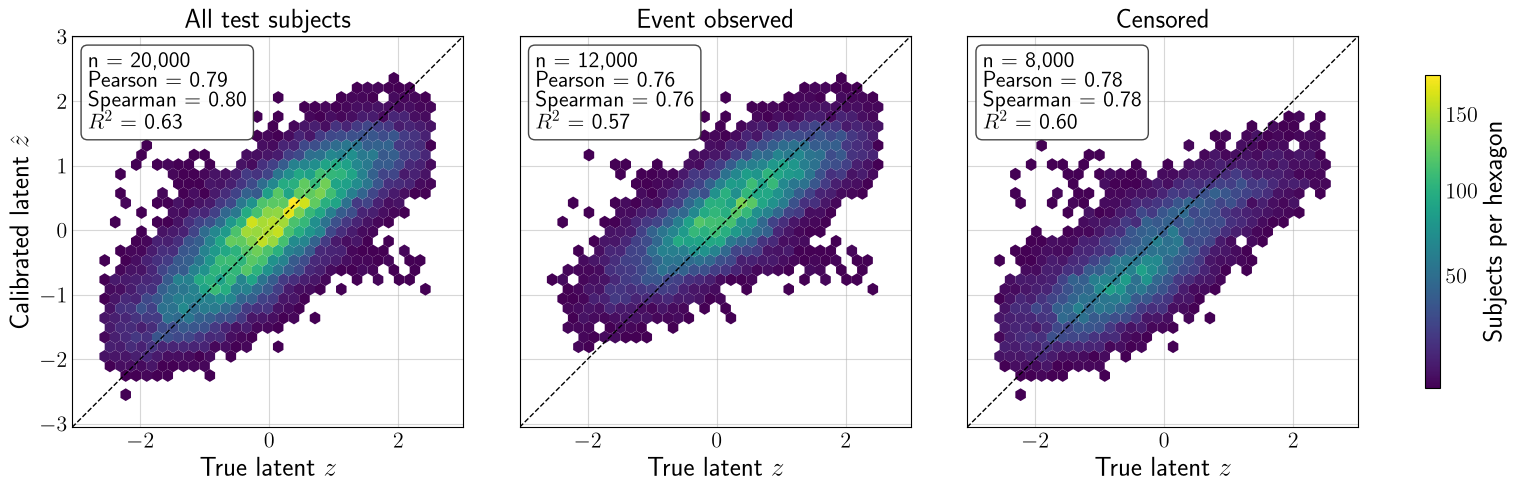

held-out subjects pooled over 10 repeats: seer_brain / gaussian / tau=0.5 (gridsize 31) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_subject_frailty_recovery.pdf


In [31]:
# Pooled held-out subjects are too many for a scatter, so the panels are hexbins
# on one grid and one colour scale, reusing the helpers of the hexbin cell.
# Censored subjects sit mostly in the low-z tail, so the SUPPORT figure's 2%
# lower clip would hide about 5% of them; the censored panel is also the
# sparsest, so a lower per-hexagon target keeps the grid from bottoming out.
FRAILTY_CLIP_PCT = (0.5, 99.5)
FRAILTY_TARGET_COUNT = 8

low, high = np.nanpercentile(
    np.r_[frailty_test["true_z"], frailty_test["learned_z_calibrated"]],
    FRAILTY_CLIP_PCT,
)
bin_pad = BIN_PAD_FRAC * (high - low)
bin_low, bin_high = low - bin_pad, high + bin_pad
extent = (bin_low, bin_high, bin_low, bin_high)
view_pad = VIEW_PAD_FRAC * (bin_high - bin_low)
view_low, view_high = bin_low - view_pad, bin_high + view_pad

panels = []
for title, mask in (
    ("All test subjects", np.ones(len(frailty_test), dtype=bool)),
    ("Event observed", frailty_test["event"].to_numpy() == 1),
    ("Censored", frailty_test["event"].to_numpy() == 0),
):
    subset = frailty_test.loc[mask]
    x = subset["true_z"].to_numpy()
    y = subset["learned_z_calibrated"].to_numpy()
    # Statistics use every subject; only the binning drops those outside the window.
    stats = {
        "n": len(subset),
        "pearson": float(pd.Series(x).corr(pd.Series(y), method="pearson")),
        "spearman": float(pd.Series(x).corr(pd.Series(y), method="spearman")),
        "r2": float(1 - np.sum((y - x) ** 2) / np.sum((x - x.mean()) ** 2)),
    }
    inside = (x >= bin_low) & (x <= bin_high) & (y >= bin_low) & (y <= bin_high)
    if (~inside).any():
        print(f"{title}: {(~inside).sum()} of {len(x)} subjects fall outside the plotted window")
    panels.append((title, x[inside], y[inside], stats))

gridsize = choose_gridsize(
    [(x, y, extent) for _, x, y, _ in panels], target=FRAILTY_TARGET_COUNT, mincnt=MINCNT
)
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.8), constrained_layout=True)
images = []
for ax, (title, x, y, stats) in zip(axes, panels):
    images.append(ax.hexbin(x, y, gridsize=gridsize, extent=extent, mincnt=MINCNT,
                            cmap=CMAP, linewidths=0, zorder=2, rasterized=True))
    # No legend: it would cover the low-z tail, and the caption defines the guide.
    ax.plot([view_low, view_high], [view_low, view_high], zorder=3, **GUIDE)
    ax.text(
        0.04, 0.96,
        f"n = {stats['n']:,}\nPearson = {stats['pearson']:.2f}\n"
        f"Spearman = {stats['spearman']:.2f}\n$R^2$ = {stats['r2']:.2f}",
        transform=ax.transAxes, va="top", zorder=4,
        bbox={"boxstyle": "round", "facecolor": "white", "edgecolor": "0.2", "alpha": 0.9},
    )
    ax.set(xlim=(view_low, view_high), ylim=(view_low, view_high), title=title,
           xlabel="True latent $z$")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, zorder=0, **GRID)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Calibrated latent $\hat{z}$")
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

norm = PowerNorm(gamma=NORM_GAMMA, vmin=MINCNT,
                 vmax=max(float(occupied_counts(image).max()) for image in images))
for image in images:
    image.set_norm(norm)
fig.colorbar(images[-1], ax=axes, label="Subjects per hexagon", shrink=0.8)

out = FIGURE_DIR / "semi_synthetic_subject_frailty_recovery.pdf"
# 400 dpi for the rasterized hexagons; axes and text stay vector.
fig.savefig(out, dpi=400)
plt.show()
print(f"{FRAILTY_SOURCE} (gridsize {gridsize}) | wrote {out}")

## Table: scalar-frailty recovery baselines

What a simpler estimator recovers of the same latent, on the same held-out subjects. The Cox--Gamma posterior frailty and the CoxPH martingale residual are refit by the `recovery_baselines` targets from the same seeds, and each refit is cross-checked against the benchmark fit's oracle IBS before these rows are written.

In [32]:
# Scalar-frailty recovery baselines against DVFM's encoder, on the same
# held-out subjects, cohorts and splits. Both baselines are refit by the
# recovery_baselines GWF targets and cross-checked against the benchmark fits.
#
# The two baselines are close in construction -- within a censoring stratum both
# are monotone in a fitted cumulative event hazard -- but they come from
# different fits, a Cox-Gamma frailty model and a plain CoxPH, and on these
# cohorts they do not track each other: see the cross-cell correlation printed
# below and the censored column on SUPPORT. They are reported side by side for
# that reason, so the comparison against DVFM does not rest on one baseline's
# hazard estimator.
from scipy.stats import wilcoxon

RECOVERY_MODELS = ["DVFM", "BayesianCoxGammaFrailty", "CoxPHMartingale"]
RECOVERY_MODEL_LABELS = {
    "DVFM": "DVFM (ours)",
    "BayesianCoxGammaFrailty": "CG Frailty posterior",
    "CoxPHMartingale": "CoxPH martingale residual",
}
RECOVERY_SUBGROUPS = ["All", "Event observed", "Censored"]
RECOVERY_TAU = float(config["evaluation"]["recovery_baseline_kendall_tau"])
RECOVERY_DATASETS = [
    str(name) for name in config["evaluation"]["recovery_baseline_datasets"]
]

baseline_path = next(
    (path / "recovery_baselines" / "recovery_rows.csv"
     for path in RESULT_CANDIDATES
     if (path / "recovery_baselines" / "recovery_rows.csv").exists()),
    None,
)
if baseline_path is None:
    raise FileNotFoundError(
        "No aggregated recovery_baselines/recovery_rows.csv. Run the "
        "recovery_baselines targets and their aggregation first."
    )
baselines = canonicalize(pd.read_csv(baseline_path))

dvfm_metric_paths = sorted(
    path for root in RESULT_CANDIDATES if root.exists()
    for path in root.rglob("latent_calibration_metrics.csv")
)
if not dvfm_metric_paths:
    raise FileNotFoundError("No DVFM latent_calibration_metrics.csv exports were found.")
dvfm_recovery = canonicalize(pd.concat(
    (pd.read_csv(path) for path in dvfm_metric_paths), ignore_index=True
))

recovery = pd.concat([dvfm_recovery, baselines], ignore_index=True)
recovery = recovery[
    recovery["split"].eq("test")
    & recovery["representation"].eq("Validation-calibrated")
    & recovery["model"].isin(RECOVERY_MODELS)
    & recovery["dataset"].isin(RECOVERY_DATASETS)
    & np.isclose(pd.to_numeric(recovery["target_kendall_tau"]), RECOVERY_TAU)
].copy()
if recovery.empty:
    raise ValueError(f"No recovery rows at tau={RECOVERY_TAU:g} for {RECOVERY_DATASETS}.")

RECOVERY_CELL = ["dataset", "copula", "repeat"]
counts = recovery.groupby(["dataset", "model", "subgroup"])["repeat"].nunique()
if not counts.eq(EXPECTED_REPEATS).all():
    raise ValueError(f"Incomplete recovery grid: {counts[~counts.eq(EXPECTED_REPEATS)].to_dict()}")

per_copula = recovery.groupby(
    ["dataset", "model", "subgroup", "copula"], as_index=False
)["spearman"].mean()
summary = per_copula.groupby(["dataset", "model", "subgroup"], as_index=False).agg(
    spearman=("spearman", "mean"), spread=("spearman", "std"),
)

table = summary.pivot_table(
    index=["dataset", "model"], columns="subgroup", values="spearman"
).reindex(columns=RECOVERY_SUBGROUPS)
spread = summary.pivot_table(
    index=["dataset", "model"], columns="subgroup", values="spread"
).reindex(columns=RECOVERY_SUBGROUPS)
formatted = pd.DataFrame(index=table.index, columns=RECOVERY_SUBGROUPS, dtype=object)
for subgroup in RECOVERY_SUBGROUPS:
    formatted[subgroup] = [
        f"{value:.3f} ({deviation:.3f})" if np.isfinite(deviation) else f"{value:.3f}"
        for value, deviation in zip(table[subgroup], spread[subgroup])
    ]
formatted = formatted.reset_index()
formatted["dataset"] = formatted["dataset"].map(dataset_label)
formatted["model"] = formatted["model"].map(RECOVERY_MODEL_LABELS)
formatted = formatted.rename(columns={"dataset": "Dataset", "model": "Estimator"})
formatted["_order"] = formatted["Estimator"].map(
    {label: index for index, label in enumerate(RECOVERY_MODEL_LABELS.values())}
)
formatted = formatted.sort_values(["Dataset", "_order"]).drop(columns="_order")

latex = formatted.to_latex(index=False, escape=False, column_format="llrrr")
table_path = TABLE_DIR / "semi_synthetic_recovery_baselines.tex"
table_path.write_text(latex, encoding="utf-8")

print(f"{DATA_SOURCE} | wrote {table_path}")
print(formatted.to_string(index=False))

# The claim the table is there to test: the gap over a scalar frailty proxy is
# concentrated on censored subjects, whose censoring time is evidence about z
# only for a model that also decodes a censoring margin loaded on that latent.
# Reported per dataset and against each baseline separately, because pooling
# hides the cells where the claim does not hold: the gap changes sign on
# SUPPORT, against the Cox-Gamma posterior among event-observed subjects and
# against the martingale residual among censored ones.
paired = recovery.pivot_table(
    index=RECOVERY_CELL + ["subgroup"], columns="model", values="spearman"
).dropna(subset=RECOVERY_MODELS)
for dataset in RECOVERY_DATASETS:
    for subgroup in RECOVERY_SUBGROUPS:
        cells = paired.xs(subgroup, level="subgroup").xs(dataset, level="dataset")
        for baseline in RECOVERY_MODELS[1:]:
            difference = cells["DVFM"] - cells[baseline]
            test = wilcoxon(difference)
            print(f"{dataset:>11} | {subgroup:<15} | DVFM - "
                  f"{RECOVERY_MODEL_LABELS[baseline]:<26} median "
                  f"{difference.median():+.3f}, DVFM ahead in "
                  f"{int((difference > 0).sum()):>2}/{len(difference)} cells, "
                  f"Wilcoxon p={test.pvalue:.3g}")
agreement = paired[RECOVERY_MODELS[1:]].dropna()
print("CG posterior vs martingale residual across cells: "
      f"Pearson r={agreement.corr().iloc[0, 1]:.3f}")

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_recovery_baselines.tex
       Dataset                 Estimator           All Event observed      Censored
  SEER (brain)               DVFM (ours) 0.787 (0.011)  0.738 (0.046) 0.772 (0.031)
  SEER (brain)      CG Frailty posterior 0.709 (0.008)  0.753 (0.038) 0.578 (0.018)
  SEER (brain) CoxPH martingale residual 0.590 (0.007)  0.613 (0.032) 0.561 (0.035)
  SEER (liver)               DVFM (ours) 0.808 (0.015)  0.762 (0.035) 0.827 (0.037)
  SEER (liver)      CG Frailty posterior 0.697 (0.008)  0.754 (0.035) 0.657 (0.029)
  SEER (liver) CoxPH martingale residual 0.602 (0.002)  0.677 (0.031) 0.685 (0.034)
SEER (stomach)               DVFM (ours) 0.780 (0.035)  0.713 (0.039) 0.789 (0.059)
SEER (stomach)      CG Frailty posterior 0.697 (0.011)  0.735 (0.042) 0.611 (0.025)
SEER (stomach) CoxPH martingale residual 0.602 (0.009)  0.604 (0.038) 0.671 (0.040)
 seer_brain | All          

## Figure: scalar-frailty recovery baselines

The same numbers as the table above, drawn so the censored-subject gap is what
you see first. Both baselines are refit on the identical cohorts and splits, so
the three estimators are scored on the same held-out subjects against the same
true latent. The event-observed column is where a scalar frailty proxy is on its
own ground: a censored subject contributes a censoring time, which is evidence
about $z$ only for a model that also decodes a censoring margin loaded on that
latent.

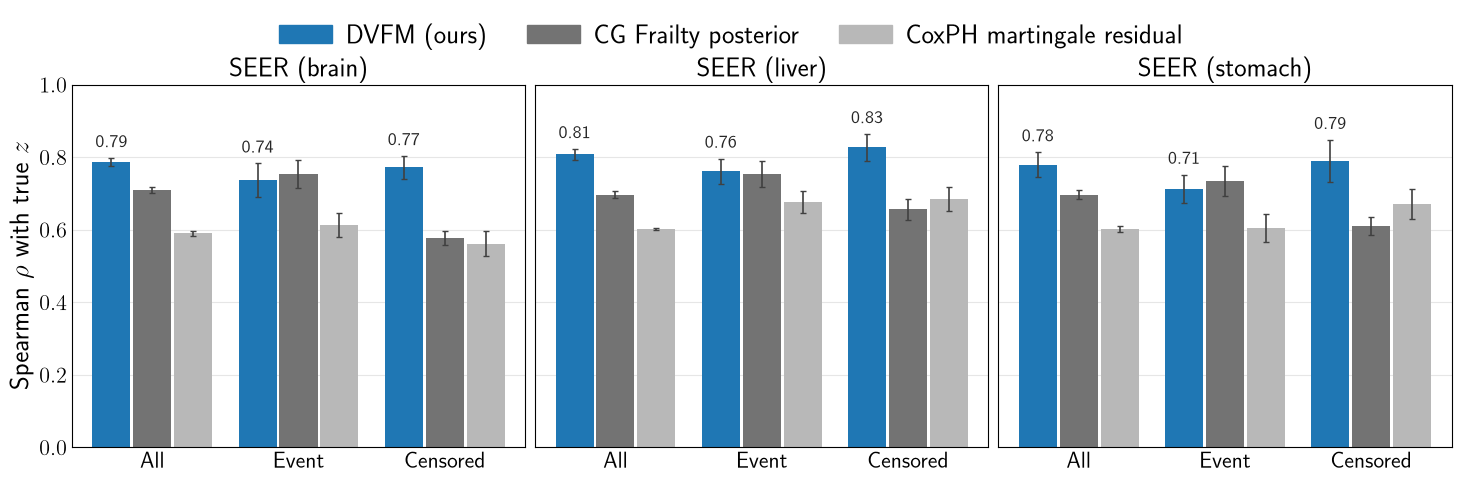

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_recovery_baselines.pdf


In [33]:
# Companion figure to the recovery-baseline table: one row of panels, one per
# recovery dataset in config order, sharing the y-axis and a single legend, in
# the layout of the model-rank figure. Bars are the mean over the four copulas
# of the seed-averaged Spearman correlation and error bars +/- 1 SD across the
# copulas -- the table's aggregation, so the two agree cell by cell. DVFM is
# emphasised and the baselines are gray context; only DVFM's bars carry a
# printed value.
from matplotlib.patches import Patch

RECOVERY_BAR_COLORS = {
    "DVFM": default_colors[0], "BayesianCoxGammaFrailty": "0.45", "CoxPHMartingale": "0.72",
}
RECOVERY_TICK_LABELS = {"All": "All", "Event observed": "Event", "Censored": "Censored"}
BAR_WIDTH = 0.26

recovery_cells = recovery.groupby(
    ["dataset", "model", "subgroup", "copula"], as_index=False
)["spearman"].mean()
recovery_datasets = list(RECOVERY_DATASETS)
recovery_stats = recovery_cells.groupby(
    ["dataset", "model", "subgroup"]
)["spearman"].agg(["mean", "std"])
# DVFM's exports exist for every dataset, so a dataset can be present while its
# baseline refits are not; require every estimator in every panel.
missing_panels = [
    (dataset, model, subgroup)
    for dataset in recovery_datasets for model in RECOVERY_MODELS
    for subgroup in RECOVERY_SUBGROUPS
    if (dataset, model, subgroup) not in recovery_stats.index
]
if missing_panels:
    raise ValueError(f"Recovery rows are missing for: {missing_panels}")
positions = np.arange(len(RECOVERY_SUBGROUPS))

fig, axes = plt.subplots(1, len(recovery_datasets), figsize=(14.5, 4.8),
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, dataset in zip(axes, recovery_datasets):
    for index, model in enumerate(RECOVERY_MODELS):
        means = [recovery_stats.loc[(dataset, model, subgroup), "mean"]
                 for subgroup in RECOVERY_SUBGROUPS]
        spread = [recovery_stats.loc[(dataset, model, subgroup), "std"]
                  for subgroup in RECOVERY_SUBGROUPS]
        bars = ax.bar(positions + (index - 1) * (BAR_WIDTH + 0.02), means, BAR_WIDTH,
                      color=RECOVERY_BAR_COLORS[model], yerr=spread, zorder=2,
                      error_kw={"elinewidth": 1.2, "capsize": 2.5, "ecolor": "0.25"})
        if model == "DVFM":
            for bar, value, deviation in zip(bars, means, spread):
                ax.text(bar.get_x() + bar.get_width() / 2, value + deviation + 0.02,
                        f"{value:.2f}", ha="center", va="bottom",
                        fontsize="small", color="0.15")
    ax.set_xticks(positions, [RECOVERY_TICK_LABELS[subgroup] for subgroup in RECOVERY_SUBGROUPS])
    ax.set_title(dataset_label(dataset))
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].set_ylim(0, 1)
axes[0].set_yticks(np.linspace(0, 1, 6))
axes[0].set_ylabel(r"Spearman $\rho$ with true $z$")
fig.legend(
    handles=[Patch(color=RECOVERY_BAR_COLORS[model], label=RECOVERY_MODEL_LABELS[model])
             for model in RECOVERY_MODELS],
    loc="outside upper center", ncol=len(RECOVERY_MODELS), frameon=False,
    columnspacing=1.5, handletextpad=0.5,
)

out = FIGURE_DIR / "semi_synthetic_recovery_baselines.pdf"
with plt.rc_context({"savefig.bbox": "standard"}):
    fig.savefig(out)
plt.show()
print(f"{DATA_SOURCE} | wrote {out}")

## Tables

The notebook writes booktabs-compatible LaTeX directly. Table 1 describes the datasets. Table 2 reports scenario-balanced ranks and paired wins/ties/losses; full dataset-by-model values belong in the supplement.

In [34]:
if characteristics is None:
    print("dataset_characteristics.csv is absent; write this file during generation to enable Table 1.")
else:
    dataset_table = characteristics.copy()
    for column in dataset_table.select_dtypes(include="number"):
        if "rate" in column.lower():
            dataset_table[column] = dataset_table[column].map(lambda value: f"{value:.2f}")
    latex = dataset_table.to_latex(
        index=False, escape=False,
        caption="Characteristics of the source datasets used for semi-synthetic evaluation.",
        label="tab:semi_synthetic_datasets",
        column_format="l" + "r" * (len(dataset_table.columns) - 1),
    )
    out = TABLE_DIR / "semi_synthetic_datasets.tex"
    out.write_text(latex, encoding="utf-8")
    print(latex)
    print(f"{DATA_SOURCE} | wrote {out}")

\begin{table}
\caption{Characteristics of the source datasets used for semi-synthetic evaluation.}
\label{tab:semi_synthetic_datasets}
\begin{tabular}{lrrrrr}
\toprule
Dataset & $N$ & Raw features & Encoded features & Original censoring rate & Split \\
\midrule
churn & 1958 & 12 & 25 & 0.52 & 70/10/20 \\
employee & 10000 & 8 & 17 & 0.76 & 70/10/20 \\
flchain & 7871 & 8 & 16 & 0.72 & 70/10/20 \\
gbsg & 686 & 8 & 8 & 0.56 & 70/10/20 \\
metabric & 1903 & 9 & 9 & 0.42 & 70/10/20 \\
mimic_iv & 10000 & 91 & 103 & 0.67 & 70/10/20 \\
nacd & 2396 & 48 & 48 & 0.36 & 70/10/20 \\
seer_brain & 10000 & 10 & 10 & 0.40 & 70/10/20 \\
seer_liver & 10000 & 14 & 14 & 0.38 & 70/10/20 \\
seer_stomach & 10000 & 14 & 14 & 0.43 & 70/10/20 \\
support & 8873 & 14 & 27 & 0.32 & 70/10/20 \\
whas & 500 & 14 & 14 & 0.57 & 70/10/20 \\
\bottomrule
\end{tabular}
\end{table}

REAL RESULTS (cross-dataset aggregate) | wrote c:\Users\cml\Desktop\dvfm-survival\paper\tables\semi_synthetic_datasets.tex


In [35]:
# Tables follow Figure 1 exactly: rank models within a paired seed, average the
# seeds, average the copulas, then take the median across datasets. Kendall's
# tau levels are never pooled -- each gets its own table, so a number here can
# be read straight off the corresponding figure panel. That includes the pool:
# these rank `ranked_results`, so the no-frailty ablation is an entry here too.

def scenario_balanced_rank_table(frame, tau_value):
    """Median across datasets of each model's mean seed-level rank."""
    subset = frame[np.isclose(frame["target_kendall_tau"], tau_value)].copy()
    if subset.empty:
        raise ValueError(f"No results for tau={tau_value:g}.")
    expected_copulas = (
        {"Independence"} if np.isclose(tau_value, 0.0) else CONFIG_POSITIVE_COPULAS
    )
    observed_copulas = set(subset["copula"].unique())
    if observed_copulas != expected_copulas:
        raise ValueError(
            f"Unexpected copulas for tau={tau_value:g}: expected "
            f"{sorted(expected_copulas)}, found {sorted(observed_copulas)}."
        )
    table = None
    for metric, label in [("oracle_ibs", "IBS"), ("oracle_ci", "CI"), ("oracle_mae", "MAE")]:
        seed_ranks = seed_level_metric_ranks(subset, metric, metric == "oracle_ci")
        repeat_counts = seed_ranks.groupby(["dataset", "copula", "model"])["repeat"].nunique()
        if not repeat_counts.eq(EXPECTED_REPEATS).all():
            incomplete = repeat_counts[~repeat_counts.eq(EXPECTED_REPEATS)]
            raise ValueError(
                f"Incomplete seed grid for tau={tau_value:g}, {metric}: {incomplete.to_dict()}"
            )
        scenario_ranks = seed_ranks.groupby(
            ["dataset", "copula", "model"], as_index=False
        )["seed_rank"].mean()
        per_dataset = scenario_ranks.groupby(
            ["dataset", "model"], as_index=False
        )["seed_rank"].mean()
        summary = per_dataset.groupby("model", as_index=False)["seed_rank"].median().rename(
            columns={"seed_rank": label}
        )
        table = summary if table is None else table.merge(summary, on="model", how="outer")
    return subset, table


def wins_ties_losses(subset, tolerance=1e-4):
    """Paired oracle-IBS record against DVFM, from the comparator's perspective."""
    dvfm = subset[subset["model"].eq("DVFM")][SEED_KEYS + ["oracle_ibs"]].rename(
        columns={"oracle_ibs": "dvfm_ibs"}
    )
    paired = subset.merge(dvfm, on=SEED_KEYS, how="left")
    paired["outcome"] = np.where(
        paired["oracle_ibs"] < paired["dvfm_ibs"] - tolerance, "W",
        np.where(paired["oracle_ibs"] > paired["dvfm_ibs"] + tolerance, "L", "T"),
    )
    counts = (
        paired.groupby(["model", "outcome"]).size().unstack(fill_value=0)
        .reindex(columns=["W", "T", "L"], fill_value=0)
    )
    return counts.astype(int).astype(str).agg("/".join, axis=1).rename("W/T/L vs DVFM")


for tau_value in CONFIG_TAU_VALUES:
    subset, rank_table = scenario_balanced_rank_table(ranked_results, tau_value)
    rank_table = rank_table.merge(
        wins_ties_losses(subset), left_on="model", right_index=True, how="left"
    )
    rank_table.loc[rank_table["model"].eq("DVFM"), "W/T/L vs DVFM"] = "--"
    rank_table["model"] = rank_table["model"].map(
        lambda name: name if name == "DVFM" else MODEL_LABELS.get(name, name)
    )
    rank_table = rank_table.sort_values("IBS").rename(
        columns={"model": "Model", "IBS": "IBS rank", "CI": "CI rank", "MAE": "MAE rank"}
    )
    for column in ["IBS rank", "CI rank", "MAE rank"]:
        rank_table[column] = rank_table[column].map(lambda value: f"{value:.2f}")
    slug = f"tau{tau_value:g}".replace(".", "p")
    latex = rank_table.to_latex(
        index=False, escape=False,
        caption=(
            rf"Semi-synthetic performance at Kendall's $\tau={tau_value:g}$. Each entry is "
            r"the median across the 12 datasets of a model's mean seed-level rank, the same "
            r"quantity plotted in the corresponding figure panel; lower is better. Wins, ties "
            r"and losses compare paired oracle-IBS seeds against DVFM from each comparator's "
            r"perspective. DVFM with $d_z=0$ is the matched no-frailty ablation, not a "
            r"competing method; it is ranked in the same pool so that its gap to DVFM is "
            r"read in the same units as every other gap in the table."
        ),
        label=f"tab:semi_synthetic_models_{slug}",
        column_format="lrrrr",
    )
    out = TABLE_DIR / f"semi_synthetic_model_summary_{slug}.tex"
    out.write_text(latex, encoding="utf-8")
    print(latex)
    print(f"{DATA_SOURCE} | tau={tau_value:g} | wrote {out}")

\begin{table}
\caption{Semi-synthetic performance at Kendall's $\tau=0$. Each entry is the median across the 12 datasets of a model's mean seed-level rank, the same quantity plotted in the corresponding figure panel; lower is better. Wins, ties and losses compare paired oracle-IBS seeds against DVFM from each comparator's perspective. DVFM with $d_z=0$ is the matched no-frailty ablation, not a competing method; it is ranked in the same pool so that its gap to DVFM is read in the same units as every other gap in the table.}
\label{tab:semi_synthetic_models_tau0}
\begin{tabular}{lrrrr}
\toprule
Model & IBS rank & CI rank & MAE rank & W/T/L vs DVFM \\
\midrule
CG Frailty & 1.55 & 2.40 & 1.75 & 110/0/10 \\
CoxPH & 3.65 & 2.45 & 4.20 & 69/1/50 \\
DVFM ($d_z{=}0$) & 4.35 & 5.40 & 4.30 & 70/2/48 \\
HACSurv & 4.50 & 3.85 & 4.45 & 66/0/54 \\
DVFM & 4.55 & 4.70 & 5.05 & -- \\
DeepSurv & 5.70 & 5.40 & 5.40 & 54/0/66 \\
MTLR & 5.75 & 6.15 & 6.05 & 44/0/76 \\
Clayton AFT & 6.95 & 7.60 & 6.15 & 26/2

## Table: absolute oracle metrics

Ranks say who is ahead, not by how much, and a rank of 2.5 is the same number
whether the gap behind it is a third of the metric or a thousandth. This table
gives the values the ranks were computed from, under the same aggregation, plus
the within-dataset relative change each model carries against DVFM.

Read the two columns differently. The level is a median over datasets whose
metrics are not on one scale -- Oracle MAE is in each dataset's own time units --
so it describes a typical value, not a comparison. The change is formed inside
each dataset before any pooling, which is what makes it comparable across them.

The two can disagree in sign for the same model, and that is the point of showing both: a model can sit above DVFM in the pooled level while beating it on most individual datasets, if the datasets where it wins are the ones with small metric values. Only the change column licenses a claim about which model is better.

In [36]:
# Absolute metric values behind the ranks, and the within-dataset relative
# change against DVFM. The aggregation is the rank tables' own -- seeds within a
# dataset x copula cell, then the copulas within a dataset -- so both tables
# describe exactly the same cells and the ranking pool is the same nine entries.
ABSOLUTE_METRICS = {
    "oracle_ibs": ("Oracle IBS", "{:.3f}"),
    "oracle_ci": ("Oracle CI", "{:.3f}"),
    "oracle_mae": ("Oracle MAE", "{:,.0f}"),
}
REFERENCE_MODEL = "DVFM"

def per_dataset_metrics(frame, tau_value):
    """One value per dataset per model: seeds, then copulas, averaged."""
    metrics = list(ABSOLUTE_METRICS)
    subset = frame[np.isclose(frame["target_kendall_tau"], tau_value)].copy()
    if subset.empty:
        raise ValueError(f"No results for tau={tau_value:g}.")
    failure = subset["numerical_failure"].fillna(False)
    if failure.dtype != bool:
        failure = failure.astype(str).str.lower().eq("true")
    values = subset[metrics].apply(pd.to_numeric, errors="coerce")
    # The rank tables substitute a worst-plus-one rank for a failed seed. A
    # metric level has no such substitute, so a failure has to stop the table
    # rather than quietly drop a cell and shift a mean.
    unusable = failure | ~np.isfinite(values).all(axis=1)
    if unusable.any():
        raise ValueError(
            f"{int(unusable.sum())} unusable rows at tau={tau_value:g}: "
            f"{subset.loc[unusable, ['dataset', 'copula', 'model']].drop_duplicates().to_dict('records')}"
        )
    per_copula = subset.groupby(["dataset", "copula", "model"], as_index=False)[metrics].mean()
    counts = per_copula.groupby(["dataset", "model"])["copula"].nunique()
    if counts.nunique() != 1:
        raise ValueError(f"Uneven copula coverage at tau={tau_value:g}: {counts.to_dict()}")
    return per_copula.groupby(["dataset", "model"], as_index=False)[metrics].mean()

metrics = list(ABSOLUTE_METRICS)
for tau_value in CONFIG_TAU_VALUES:
    per_dataset_values = per_dataset_metrics(ranked_results, tau_value)
    reference = per_dataset_values[per_dataset_values["model"].eq(REFERENCE_MODEL)]
    if reference.empty:
        raise ValueError(f"No {REFERENCE_MODEL} rows to compare against at tau={tau_value:g}.")
    relative = per_dataset_values.merge(
        reference.drop(columns="model"), on="dataset",
        suffixes=("", "_reference"), validate="many_to_one",
    )
    for metric in metrics:
        relative[f"{metric}_change"] = (
            (relative[metric] - relative[f"{metric}_reference"])
            / relative[f"{metric}_reference"].abs()
        )
    level = per_dataset_values.groupby("model")[metrics].median()
    change = relative.groupby("model")[[f"{metric}_change" for metric in metrics]].median()
    spread = relative.groupby("model")[[f"{metric}_change" for metric in metrics]].quantile([0.25, 0.75])

    table = pd.DataFrame({"Model": level.index})
    for metric in metrics:
        label, number_format = ABSOLUTE_METRICS[metric]
        table[label] = [number_format.format(value) for value in level[metric]]
        table[f"{label} vs DVFM"] = [
            "--" if model == REFERENCE_MODEL else f"{value:+.1%}".replace("%", r"\%")
            for model, value in zip(level.index, change[f"{metric}_change"])
        ]
    table["Model"] = table["Model"].map(
        lambda name: name if name == "DVFM" else MODEL_LABELS.get(name, name)
    )
    table = table.iloc[np.argsort(level["oracle_ibs"].to_numpy())].reset_index(drop=True)

    slug = f"tau{tau_value:g}".replace(".", "p")
    latex = table.to_latex(
        index=False, escape=False,
        caption=(
            rf"Absolute oracle metrics at Kendall's $\tau={tau_value:g}$, the values behind "
            rf"the ranks in Table~\ref{{tab:semi_synthetic_models_{slug}}}. Seeds are averaged "
            r"within each dataset $\times$ copula cell and the copulas within each dataset; the "
            r"level is the median of those per-dataset values and the change beside it is the "
            r"median across datasets of the within-dataset relative change against DVFM, "
            r"$(\text{model} - \text{DVFM})/|\text{DVFM}|$. Levels are not comparable across "
            r"datasets, since Oracle MAE carries each dataset's own time scale; the changes are, "
            r"because they are formed inside a dataset before pooling. Lower is better for IBS "
            r"and MAE, higher for CI."
        ),
        label=f"tab:semi_synthetic_absolute_metrics_{slug}",
        column_format="l" + "rr" * len(metrics),
    )
    out = TABLE_DIR / f"semi_synthetic_absolute_metrics_{slug}.tex"
    out.write_text(latex, encoding="utf-8")
    print(table.to_string(index=False))
    print(f"{DATA_SOURCE} | tau={tau_value:g} | wrote {out}")
    print("interquartile range of the within-dataset change:")
    for metric in metrics:
        quartiles = spread[f"{metric}_change"].unstack()
        print(f"  {ABSOLUTE_METRICS[metric][0]}: " + ", ".join(
            f"{model} [{quartiles.loc[model, 0.25]:+.1%}, {quartiles.loc[model, 0.75]:+.1%}]"
            for model in level.index if model != REFERENCE_MODEL
        ))
    print()

           Model Oracle IBS Oracle IBS vs DVFM Oracle CI Oracle CI vs DVFM Oracle MAE Oracle MAE vs DVFM
      CG Frailty      0.106             -6.7\%     0.668            +1.6\%        406             -3.3\%
DVFM ($d_z{=}0$)      0.116             -1.0\%     0.668            -0.1\%        415             -0.3\%
            DVFM      0.120                 --     0.657                --        422                 --
         HACSurv      0.122             -1.6\%     0.665            +0.8\%        411             +0.6\%
     Clayton AFT      0.125             +3.9\%     0.652            -0.3\%        427             +0.9\%
           CoxPH      0.126             -2.0\%     0.652            +1.0\%        461             -0.7\%
            MTLR      0.126             +4.6\%     0.655            -1.2\%        438             +4.1\%
        DeepSurv      0.131             +3.3\%     0.653            +0.2\%        537             +1.8\%
             RSF      0.134             +5.6\%     0.64